# Explainable Academic Pathway and Bridge Course Recommender

## Rwanda Academic Pathway Recommender

This notebook develops and evaluates a machine-learning model that recommends suitable higher-education program categories for students in Rwanda.

The recommendation is based on the student's education background, academic pathway, strongest and weakest subjects, interests, career preferences, academic performance, and digital skills.

The system also provides:

- Recommended bridge courses
- Alternative academic pathways
- Rule-based eligibility guidance
- Explainable recommendations
- Model performance evaluation

### Project Objective

The objective is to develop an explainable hybrid recommendation system that combines machine learning with academic eligibility rules to support students when selecting suitable university programs and alternative learning pathways.

## 1. Import Required Libraries

This section imports the Python libraries required for data manipulation, visualisation, preprocessing, model training, evaluation, and model saving.

In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt

# Data preprocessing and model development
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine-learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Saving the trained model
import joblib

# General settings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Inspect the Dataset

This section loads the student pathway dataset and performs an initial inspection of its structure, dimensions, columns, and sample records.

In [5]:
from google.colab import files

uploaded = files.upload()

Saving rwandan_student_pathway_dataset.xlsx to rwandan_student_pathway_dataset.xlsx


In [6]:
# Automatically retrieve the uploaded filename
DATA_PATH = next(iter(uploaded))

# Load the Excel dataset
df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")
print(f"File used: {DATA_PATH}")
print(f"Number of records: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
File used: rwandan_student_pathway_dataset.xlsx
Number of records: 10,605
Number of columns: 14


,StudentID,EducationType,Pathway,Stream_or_Trade,BestSubject,WeakestSubject,InterestArea,AverageScoreRange,DigitalSkillLevel,CareerCluster,RecommendedProgram,RecommendedBridgeCourse,AlternativePathway,CareerDream
0,STU00001,General Education,Mathematics and Sciences,Stream 2,Physics,Geography,STEM Fields,60–69%,Advanced,Medicine & Health,Bachelor of Medicine and Bachelor of Surgery (...,"Advanced Human Biology Lab Foundations, Medica...",BSc in Biomedical Laboratory Sciences,Medicine and Surgery (MBChB) Specialist
1,STU00002,General Education,Mathematics and Sciences,Stream 1,Physics,History,STEM Fields,90–100%,Beginner,Medicine & Health,BSc in General Nursing,"Advanced Human Biology Lab Foundations, Medica...",BSc in Biomedical Laboratory Sciences,General Nursing Specialist
2,STU00003,General Education,Arts and Humanities,General Arts,Geography,Chemistry,Humanities & Business,80–89%,Beginner,Law & Governance,BA in Public Administration,"Legal Writing and Critical Argumentation, Publ...",Bachelor of Laws (LLB),Public Administration Specialist
3,STU00004,General Education,Arts and Humanities,General Arts,History,Physics,Humanities & Business,80–89%,Advanced,Law & Governance,Bachelor of Laws (LLB),"Legal Writing and Critical Argumentation, Publ...",BA in Public Administration,Laws (LLB) Specialist
4,STU00005,General Education,Mathematics and Sciences,Stream 2,Biology,History,STEM Fields,80–89%,Advanced,Engineering and Technology,BSc in Electrical Engineering,"Calculus & Linear Algebra Module, Physics Mech...",BSc in Software Engineering,Electrical Engineering Specialist


## 3. Dataset Quality Assessment

This section checks the dataset structure, data types, missing values, duplicate records, duplicate student identifiers, and required modelling columns before data preparation begins.

In [7]:
# Required columns expected in the dataset
required_columns = [
    "StudentID",
    "EducationType",
    "Pathway",
    "Stream_or_Trade",
    "BestSubject",
    "WeakestSubject",
    "InterestArea",
    "AverageScoreRange",
    "DigitalSkillLevel",
    "CareerCluster",
    "RecommendedProgram",
    "RecommendedBridgeCourse",
    "AlternativePathway",
    "CareerDream"
]

# Check whether any required columns are missing
missing_required_columns = [
    column for column in required_columns
    if column not in df.columns
]

# Check dataset quality
missing_values = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()
duplicate_student_ids = df["StudentID"].duplicated().sum()

print("DATASET QUALITY SUMMARY")
print("-" * 40)
print(f"Dataset shape: {df.shape}")
print(f"Missing values: {missing_values}")
print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate Student IDs: {duplicate_student_ids}")
print(f"Missing required columns: {missing_required_columns}")

# Create a detailed column summary
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

display(column_summary)

DATASET QUALITY SUMMARY
----------------------------------------
Dataset shape: (10605, 14)
Missing values: 0
Duplicate rows: 0
Duplicate Student IDs: 0
Missing required columns: []


,Column,Data Type,Missing Values,Unique Values
0,StudentID,object,0,10605
1,EducationType,object,0,2
2,Pathway,object,0,4
3,Stream_or_Trade,object,0,16
4,BestSubject,object,0,13
5,WeakestSubject,object,0,11
6,InterestArea,object,0,4
7,AverageScoreRange,object,0,4
8,DigitalSkillLevel,object,0,3
9,CareerCluster,object,0,17


## 4. Categorical Data Cleaning and Consistency Validation

This section removes unnecessary spaces from text values and verifies that each student's education type, pathway, and stream or trade are logically consistent. No modelling variables are removed at this stage.

In [8]:
# Create a separate working copy to preserve the original dataset
df_clean = df.copy()

# Identify all text columns
text_columns = df_clean.select_dtypes(include="object").columns

# Remove leading, trailing, and repeated internal spaces
for column in text_columns:
    df_clean[column] = (
        df_clean[column]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Define valid education-pathway relationships
valid_general_pathways = {
    "Mathematics and Sciences",
    "Arts and Humanities",
    "Languages"
}

# Check for inconsistent education-pathway records
invalid_general_records = df_clean[
    (df_clean["EducationType"] == "General Education")
    & (~df_clean["Pathway"].isin(valid_general_pathways))
]

invalid_tvet_records = df_clean[
    (df_clean["EducationType"] == "TVET")
    & (df_clean["Pathway"] != "TVET Route")
]

# Check the Student ID structure
invalid_student_ids = df_clean[
    ~df_clean["StudentID"].str.match(r"^STU\d{5}$", na=False)
]

print("CATEGORICAL CONSISTENCY SUMMARY")
print("-" * 45)
print(f"Records after text cleaning: {len(df_clean):,}")
print(f"Invalid General Education pathways: {len(invalid_general_records)}")
print(f"Invalid TVET pathways: {len(invalid_tvet_records)}")
print(f"Invalid Student ID formats: {len(invalid_student_ids)}")
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

# Show the relationship between education type and pathway
education_pathway_table = pd.crosstab(
    df_clean["EducationType"],
    df_clean["Pathway"],
    margins=True
)

display(education_pathway_table)

CATEGORICAL CONSISTENCY SUMMARY
---------------------------------------------
Records after text cleaning: 10,605
Invalid General Education pathways: 0
Invalid TVET pathways: 0
Invalid Student ID formats: 0
Missing values after cleaning: 0


Pathway,Arts and Humanities,Languages,Mathematics and Sciences,TVET Route,All
EducationType,,,,,
General Education,2489,2579,2515,0,7583
TVET,0,0,0,3022,3022
All,2489,2579,2515,3022,10605


## 5. Create the Recommended Program Category

The original dataset contains 42 individual recommended university programs. To create a suitable multiclass classification target, related programs are grouped into 16 broader academic program categories.

The grouping is based only on the existing `RecommendedProgram` column. Student-profile features are not used to construct the target because they will later be used as model predictors.

In [9]:
# Transparent grouping of the 42 original programs into 16 categories
PROGRAM_CATEGORY_GROUPS = {
    "Medicine and Surgery": [
        "Bachelor of Medicine and Bachelor of Surgery (MBChB)"
    ],

    "Nursing and Midwifery": [
        "BSc in General Nursing"
    ],

    "Pharmacy and Pharmaceutical Sciences": [
        "Bachelor of Pharmacy (BPharm)"
    ],

    "Biomedical Laboratory Sciences": [
        "BSc in Biomedical Laboratory Sciences"
    ],

    "Biotechnology and Applied Biosciences": [
        "BSc in Biotechnology"
    ],

    "Data Science, Statistics and Analytics": [
        "BSc in Data Science",
        "BSc in Statistics"
    ],

    "Computing, Software and Information Technology": [
        "BSc in Computer Science",
        "BSc in Computer Engineering",
        "BSc in Cybersecurity",
        "BSc in Software Engineering"
    ],

    "Engineering, Construction and Technical Systems": [
        "BSc in Civil Engineering",
        "BSc in Electrical Engineering",
        "BSc in Electrical and Electronics Engineering",
        "BSc in Mechanical Engineering",
        "BSc in Urban and Regional Planning",
        "BSc in Water and Environmental Engineering"
    ],

    "Business, Finance and Economics": [
        "BBA in Entrepreneurship",
        "BBA in Finance",
        "Bachelor of Business Administration (BBA) in Finance",
        "BSc in Economics"
    ],

    "Law, Governance and International Relations": [
        "Bachelor of Laws (LLB)",
        "BA in Public Administration",
        "BA in International Relations"
    ],

    "Social Sciences, Psychology and Community Development": [
        "BA in Clinical Psychology",
        "BA in Development Studies",
        "BA in Social Work",
        "BA in Sociology"
    ],

    "Education and Teacher Training": [
        "Bachelor of Education (Arts)",
        "Bachelor of Education in Educational Leadership"
    ],

    "Languages, Communication and Media": [
        "BA in Communication, PR, or Media Studies",
        "BA in Corporate Communication",
        "BA in English Literature",
        "BA in Journalism and Communication",
        "BA in Translation and Interpretation"
    ],

    "Tourism and Hospitality Management": [
        "BA in Tourism and Hospitality Management"
    ],

    "Agriculture, Food and Environmental Studies": [
        "BSc in Crop Science",
        "BSc in Environmental Science",
        "BSc in Food Science and Technology",
        "BSc in Geography"
    ],

    "Creative Arts, Fashion and Digital Design": [
        "BA in Creative Arts",
        "BA in Fashion Design"
    ]
}

# Convert the category groups into a direct program-to-category mapping
program_to_category = {}

for category, programs in PROGRAM_CATEGORY_GROUPS.items():
    for program in programs:
        if program in program_to_category:
            raise ValueError(
                f"The program '{program}' has been assigned to more than one category."
            )

        program_to_category[program] = category

# Check whether every original program has been mapped
original_programs = set(df_clean["RecommendedProgram"].unique())
mapped_programs = set(program_to_category.keys())

unmapped_programs = sorted(original_programs - mapped_programs)
unused_mapping_entries = sorted(mapped_programs - original_programs)

print("TARGET MAPPING VALIDATION")
print("-" * 45)
print(f"Original recommended programs: {len(original_programs)}")
print(f"Programs included in the mapping: {len(mapped_programs)}")
print(f"Unmapped programs: {unmapped_programs}")
print(f"Unused mapping entries: {unused_mapping_entries}")

# Stop execution if any original program is missing
if unmapped_programs:
    raise ValueError(
        "Some recommended programs have not been assigned to a category."
    )

# Create the modelling target
df_clean["RecommendedProgramCategory"] = (
    df_clean["RecommendedProgram"].map(program_to_category)
)

print("\nTARGET VARIABLE SUMMARY")
print("-" * 45)
print(f"Number of target categories: "
      f"{df_clean['RecommendedProgramCategory'].nunique()}")
print(f"Missing target values: "
      f"{df_clean['RecommendedProgramCategory'].isnull().sum()}")

target_distribution = (
    df_clean["RecommendedProgramCategory"]
    .value_counts()
    .rename_axis("Recommended Program Category")
    .reset_index(name="Number of Students")
)

display(target_distribution)

TARGET MAPPING VALIDATION
---------------------------------------------
Original recommended programs: 42
Programs included in the mapping: 42
Unmapped programs: []
Unused mapping entries: []

TARGET VARIABLE SUMMARY
---------------------------------------------
Number of target categories: 16
Missing target values: 0


,Recommended Program Category,Number of Students
0,"Engineering, Construction and Technical Systems",1635
1,"Languages, Communication and Media",1265
2,"Computing, Software and Information Technology",1076
3,"Business, Finance and Economics",889
4,"Agriculture, Food and Environmental Studies",888
5,"Law, Governance and International Relations",880
6,"Social Sciences, Psychology and Community Deve...",825
7,"Creative Arts, Fashion and Digital Design",712
8,Education and Teacher Training,677
9,Tourism and Hospitality Management,476


## 6. Exploratory Data Analysis

This section examines the distribution of students across education types, academic pathways, and recommended program categories.

The analysis helps identify class imbalance and confirms whether the dataset represents both General Education and TVET learners.

In [10]:
# Create summary distributions
education_type_distribution = (
    df_clean["EducationType"]
    .value_counts()
    .sort_values(ascending=False)
)

pathway_distribution = (
    df_clean["Pathway"]
    .value_counts()
    .sort_values(ascending=False)
)

target_counts = (
    df_clean["RecommendedProgramCategory"]
    .value_counts()
    .sort_values(ascending=True)
)

print("EXPLORATORY DATA SUMMARY")
print("-" * 45)
print("\nEducation Type Distribution:")
print(education_type_distribution)

print("\nPathway Distribution:")
print(pathway_distribution)

print("\nTarget Category Balance:")
print(f"Largest category: {target_counts.idxmax()} "
      f"({target_counts.max():,} students)")
print(f"Smallest category: {target_counts.idxmin()} "
      f"({target_counts.min():,} students)")
print(f"Imbalance ratio: {target_counts.max() / target_counts.min():.2f}:1")

EXPLORATORY DATA SUMMARY
---------------------------------------------

Education Type Distribution:
EducationType
General Education    7583
TVET                 3022
Name: count, dtype: int64

Pathway Distribution:
Pathway
TVET Route                  3022
Languages                   2579
Mathematics and Sciences    2515
Arts and Humanities         2489
Name: count, dtype: int64

Target Category Balance:
Largest category: Engineering, Construction and Technical Systems (1,635 students)
Smallest category: Nursing and Midwifery (159 students)
Imbalance ratio: 10.28:1


Visualisation 1: Education type

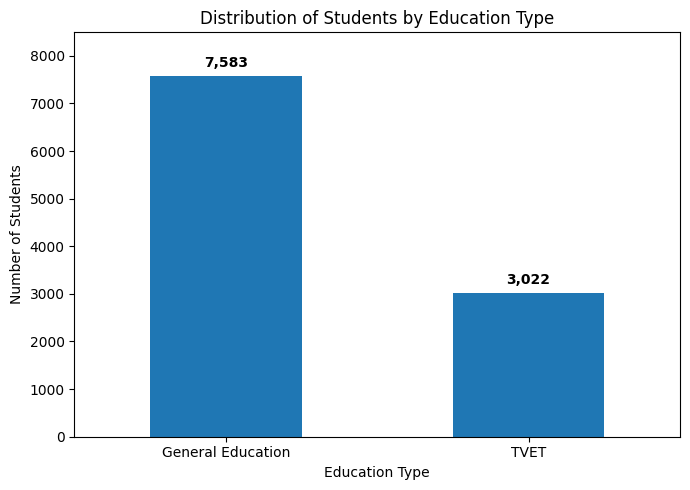

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

education_type_distribution.plot(
    kind="bar",
    ax=ax
)

# Add count labels above the bars
ax.bar_label(
    ax.containers[0],
    labels=[f"{value:,.0f}" for value in education_type_distribution.values],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

ax.set_title("Distribution of Students by Education Type")
ax.set_xlabel("Education Type")
ax.set_ylabel("Number of Students")
ax.set_xticklabels(
    education_type_distribution.index,
    rotation=0
)

# Add space above labels
ax.set_ylim(
    0,
    education_type_distribution.max() * 1.12
)

plt.tight_layout()
plt.show()

Visualisation 2: Academic pathway

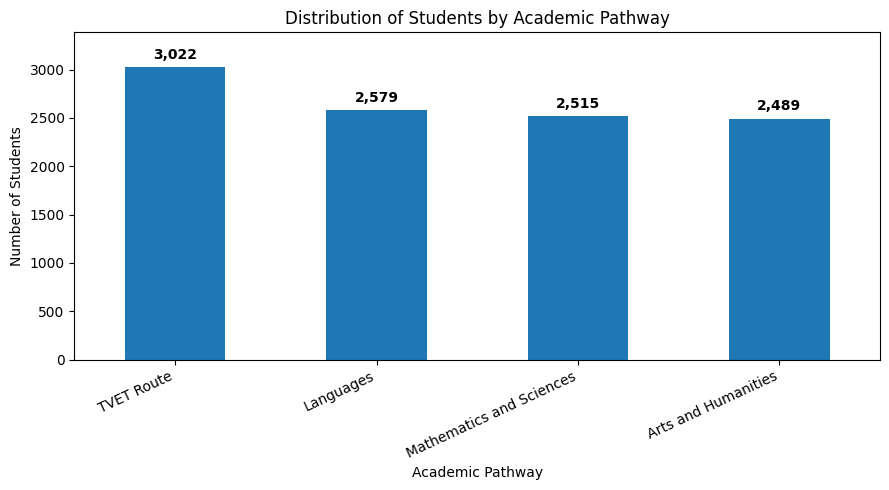

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

pathway_distribution.plot(
    kind="bar",
    ax=ax
)

# Add count labels above the bars
ax.bar_label(
    ax.containers[0],
    labels=[f"{value:,.0f}" for value in pathway_distribution.values],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

ax.set_title("Distribution of Students by Academic Pathway")
ax.set_xlabel("Academic Pathway")
ax.set_ylabel("Number of Students")
ax.set_xticklabels(
    pathway_distribution.index,
    rotation=25,
    ha="right"
)

# Add space above labels
ax.set_ylim(
    0,
    pathway_distribution.max() * 1.12
)

plt.tight_layout()
plt.show()

Visualisation 3: Target-category distribution

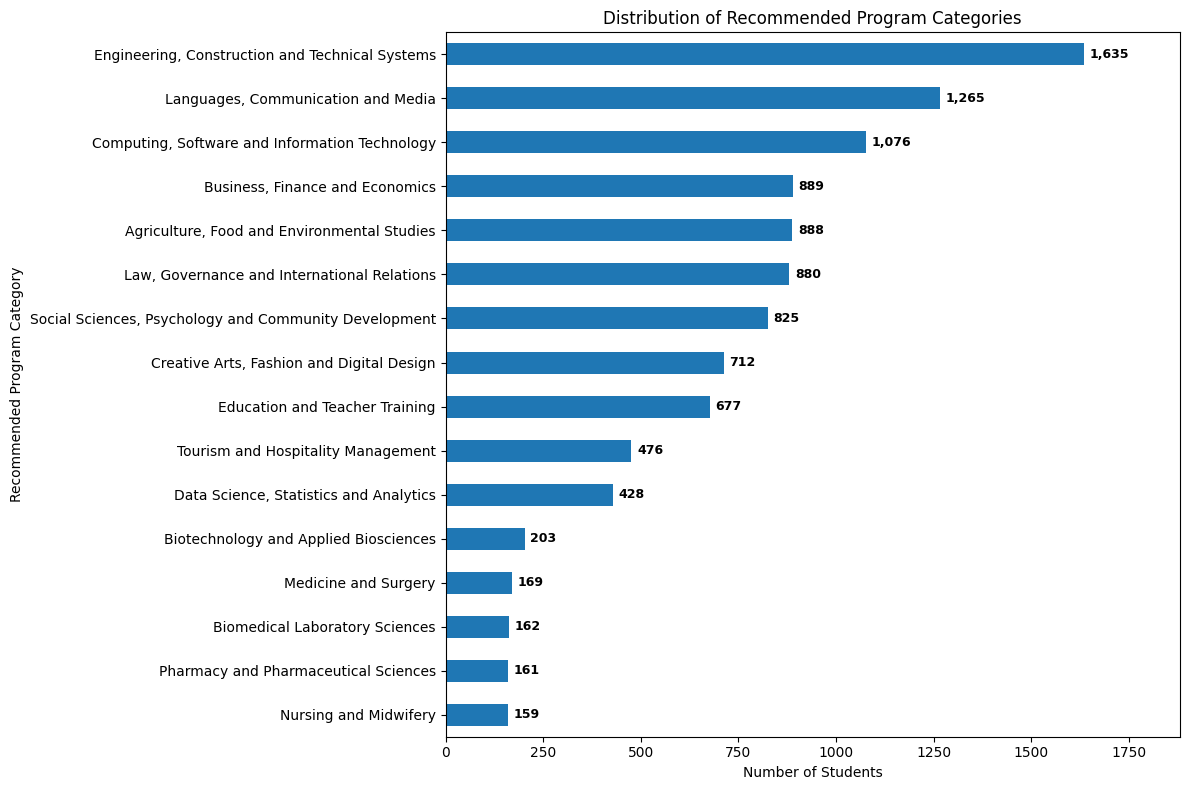

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

target_counts.plot(
    kind="barh",
    ax=ax
)

# Add count labels at the end of each bar
ax.bar_label(
    ax.containers[0],
    labels=[f"{value:,.0f}" for value in target_counts.values],
    padding=4,
    fontsize=9,
    fontweight="bold"
)

ax.set_title("Distribution of Recommended Program Categories")
ax.set_xlabel("Number of Students")
ax.set_ylabel("Recommended Program Category")

# Add space for labels at the end of the bars
ax.set_xlim(
    0,
    target_counts.max() * 1.15
)

plt.tight_layout()
plt.show()

### Exploratory Analysis Interpretation

The dataset contains both General Education and TVET students, although General Education students form the majority.

The four academic routes are well represented, with 3,022 TVET students and approximately 2,500 students in each General Education pathway.

The recommended program categories are not equally distributed. Engineering, Construction and Technical Systems is the largest category, while Nursing and Midwifery is the smallest. This imbalance makes accuracy alone insufficient for model evaluation. Therefore, macro precision, macro recall, and macro F1-score will also be used because they give equal importance to each target category.

## 7. Feature Selection and Leakage Prevention

The model uses student-profile information that would be available before a recommendation is generated.

The following columns are excluded:

- `StudentID` because it is only a record identifier.
- `RecommendedProgram` because it is the original recommendation used to construct the target.
- `RecommendedBridgeCourse` because it is an output of the recommendation system.
- `AlternativePathway` because it is another system output.
- `CareerDream` because it is closely derived from the recommended program and could introduce target leakage.

The target variable is `RecommendedProgramCategory`.

In [14]:
# Student-profile features used for model training
FEATURE_COLUMNS = [
    "EducationType",
    "Pathway",
    "Stream_or_Trade",
    "BestSubject",
    "WeakestSubject",
    "InterestArea",
    "AverageScoreRange",
    "DigitalSkillLevel",
    "CareerCluster"
]

TARGET_COLUMN = "RecommendedProgramCategory"

# Columns intentionally excluded from model training
EXCLUDED_COLUMNS = [
    "StudentID",
    "RecommendedProgram",
    "RecommendedBridgeCourse",
    "AlternativePathway",
    "CareerDream"
]

# Create feature matrix and target vector
X = df_clean[FEATURE_COLUMNS].copy()
y = df_clean[TARGET_COLUMN].copy()

# Validate the selected data
missing_feature_columns = [
    column for column in FEATURE_COLUMNS
    if column not in df_clean.columns
]

missing_values_in_features = X.isnull().sum().sum()
missing_values_in_target = y.isnull().sum()

print("FEATURE SELECTION SUMMARY")
print("-" * 45)
print(f"Number of selected features: {len(FEATURE_COLUMNS)}")
print(f"Number of student records: {len(X):,}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Missing feature columns: {missing_feature_columns}")
print(f"Missing values in features: {missing_values_in_features}")
print(f"Missing values in target: {missing_values_in_target}")
print(f"Number of target categories: {y.nunique()}")

# Summary of the selected features
feature_summary = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Data Type": [X[column].dtype for column in FEATURE_COLUMNS],
    "Unique Values": [X[column].nunique() for column in FEATURE_COLUMNS],
    "Example Value": [X[column].iloc[0] for column in FEATURE_COLUMNS]
})

display(feature_summary)

FEATURE SELECTION SUMMARY
---------------------------------------------
Number of selected features: 9
Number of student records: 10,605
Feature matrix shape: (10605, 9)
Target vector shape: (10605,)
Missing feature columns: []
Missing values in features: 0
Missing values in target: 0
Number of target categories: 16


,Feature,Data Type,Unique Values,Example Value
0,EducationType,object,2,General Education
1,Pathway,object,4,Mathematics and Sciences
2,Stream_or_Trade,object,16,Stream 2
3,BestSubject,object,13,Physics
4,WeakestSubject,object,11,Geography
5,InterestArea,object,4,STEM Fields
6,AverageScoreRange,object,4,60–69%
7,DigitalSkillLevel,object,3,Advanced
8,CareerCluster,object,17,Medicine & Health


In [15]:
# Student-profile features used for model training
FEATURE_COLUMNS = [
    "EducationType",
    "Pathway",
    "Stream_or_Trade",
    "BestSubject",
    "WeakestSubject",
    "InterestArea",
    "AverageScoreRange",
    "DigitalSkillLevel",
    "CareerCluster"
]

TARGET_COLUMN = "RecommendedProgramCategory"

# Columns intentionally excluded from model training
EXCLUDED_COLUMNS = [
    "StudentID",
    "RecommendedProgram",
    "RecommendedBridgeCourse",
    "AlternativePathway",
    "CareerDream"
]

# Create feature matrix and target vector
X = df_clean[FEATURE_COLUMNS].copy()
y = df_clean[TARGET_COLUMN].copy()

# Validate the selected data
missing_feature_columns = [
    column for column in FEATURE_COLUMNS
    if column not in df_clean.columns
]

missing_values_in_features = X.isnull().sum().sum()
missing_values_in_target = y.isnull().sum()

print("FEATURE SELECTION SUMMARY")
print("-" * 45)
print(f"Number of selected features: {len(FEATURE_COLUMNS)}")
print(f"Number of student records: {len(X):,}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Missing feature columns: {missing_feature_columns}")
print(f"Missing values in features: {missing_values_in_features}")
print(f"Missing values in target: {missing_values_in_target}")
print(f"Number of target categories: {y.nunique()}")

# Summary of the selected features
feature_summary = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Data Type": [X[column].dtype for column in FEATURE_COLUMNS],
    "Unique Values": [X[column].nunique() for column in FEATURE_COLUMNS],
    "Example Value": [X[column].iloc[0] for column in FEATURE_COLUMNS]
})

display(feature_summary)

FEATURE SELECTION SUMMARY
---------------------------------------------
Number of selected features: 9
Number of student records: 10,605
Feature matrix shape: (10605, 9)
Target vector shape: (10605,)
Missing feature columns: []
Missing values in features: 0
Missing values in target: 0
Number of target categories: 16


,Feature,Data Type,Unique Values,Example Value
0,EducationType,object,2,General Education
1,Pathway,object,4,Mathematics and Sciences
2,Stream_or_Trade,object,16,Stream 2
3,BestSubject,object,13,Physics
4,WeakestSubject,object,11,Geography
5,InterestArea,object,4,STEM Fields
6,AverageScoreRange,object,4,60–69%
7,DigitalSkillLevel,object,3,Advanced
8,CareerCluster,object,17,Medicine & Health


## 8. Stratified Training and Test Split

The dataset is divided into a development set and an untouched final test set.

- 80% of the records are used for model development and cross-validation.
- 20% are reserved for final model evaluation.
- Stratification preserves the distribution of all 16 target categories in both sets.

The final test set will not be used during model comparison or model selection.

In [16]:
# Create an 80% development set and a 20% final test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("STRATIFIED DATA SPLIT SUMMARY")
print("-" * 45)
print(f"Complete dataset: {len(X):,} records")
print(f"Development set: {len(X_train):,} records")
print(f"Final test set: {len(X_test):,} records")
print(f"Training percentage: {len(X_train) / len(X) * 100:.1f}%")
print(f"Testing percentage: {len(X_test) / len(X) * 100:.1f}%")
print(f"Target classes in development set: {y_train.nunique()}")
print(f"Target classes in final test set: {y_test.nunique()}")

# Compare class proportions in the complete, training, and test datasets
class_distribution_comparison = pd.DataFrame({
    "Complete Dataset (%)": y.value_counts(normalize=True) * 100,
    "Development Set (%)": y_train.value_counts(normalize=True) * 100,
    "Final Test Set (%)": y_test.value_counts(normalize=True) * 100
}).round(2)

# Arrange categories alphabetically
class_distribution_comparison = (
    class_distribution_comparison
    .sort_index()
)

display(class_distribution_comparison)

STRATIFIED DATA SPLIT SUMMARY
---------------------------------------------
Complete dataset: 10,605 records
Development set: 8,484 records
Final test set: 2,121 records
Training percentage: 80.0%
Testing percentage: 20.0%
Target classes in development set: 16
Target classes in final test set: 16


,Complete Dataset (%),Development Set (%),Final Test Set (%)
RecommendedProgramCategory,,,
"Agriculture, Food and Environmental Studies",8.37,8.37,8.39
Biomedical Laboratory Sciences,1.53,1.53,1.51
Biotechnology and Applied Biosciences,1.91,1.91,1.93
"Business, Finance and Economics",8.38,8.38,8.39
"Computing, Software and Information Technology",10.15,10.15,10.14
"Creative Arts, Fashion and Digital Design",6.71,6.72,6.69
"Data Science, Statistics and Analytics",4.04,4.03,4.05
Education and Teacher Training,6.38,6.39,6.36
"Engineering, Construction and Technical Systems",15.42,15.42,15.42


In [17]:
from sklearn.preprocessing import OneHotEncoder

In [18]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

## 9. Feature Preprocessing

The selected model inputs are categorical. Two preprocessing strategies are applied:

- Nominal features are transformed using one-hot encoding because their categories have no numerical order.
- `AverageScoreRange` and `DigitalSkillLevel` are transformed using ordinal encoding because their categories follow a meaningful progression.

The preprocessing pipeline also supports previously unseen categories so that new student profiles can be processed safely during deployment.

In [19]:
# Nominal categorical features with no natural order
NOMINAL_FEATURES = [
    "EducationType",
    "Pathway",
    "Stream_or_Trade",
    "BestSubject",
    "WeakestSubject",
    "InterestArea",
    "CareerCluster"
]

# Ordered categorical features
ORDINAL_FEATURES = [
    "AverageScoreRange",
    "DigitalSkillLevel"
]

# Confirm the actual values before defining their order
print("AVERAGE SCORE RANGE VALUES")
print(sorted(X_train["AverageScoreRange"].unique()))

print("\nDIGITAL SKILL LEVEL VALUES")
print(sorted(X_train["DigitalSkillLevel"].unique()))

AVERAGE SCORE RANGE VALUES
['60–69%', '70–79%', '80–89%', '90–100%']

DIGITAL SKILL LEVEL VALUES
['Advanced', 'Beginner', 'Intermediate']


In [20]:
# Define the correct category order
score_range_order = [
    "50–59%",
    "60–69%",
    "70–79%",
    "80–89%",
    "90–100%"
]

digital_skill_order = [
    "Beginner",
    "Intermediate",
    "Advanced"
]

# One-hot encoder for nominal variables
nominal_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# Ordinal encoder for ordered variables
ordinal_encoder = OrdinalEncoder(
    categories=[
        score_range_order,
        digital_skill_order
    ],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Combine the transformations
preprocessor = ColumnTransformer(
    transformers=[
        (
            "nominal",
            nominal_encoder,
            NOMINAL_FEATURES
        ),
        (
            "ordinal",
            ordinal_encoder,
            ORDINAL_FEATURES
        )
    ],
    remainder="drop"
)

# Fit only on the development data
X_train_transformed = preprocessor.fit_transform(X_train)

print("PREPROCESSING SUMMARY")
print("-" * 45)
print(f"Supported score ranges: {score_range_order}")
print(f"Supported digital skill levels: {digital_skill_order}")
print(f"Original development shape: {X_train.shape}")
print(f"Transformed development shape: {X_train_transformed.shape}")
print(f"Nominal features: {len(NOMINAL_FEATURES)}")
print(f"Ordinal features: {len(ORDINAL_FEATURES)}")
print(f"Missing values after transformation: "
      f"{np.isnan(X_train_transformed.data).sum()}")

PREPROCESSING SUMMARY
---------------------------------------------
Supported score ranges: ['50–59%', '60–69%', '70–79%', '80–89%', '90–100%']
Supported digital skill levels: ['Beginner', 'Intermediate', 'Advanced']
Original development shape: (8484, 9)
Transformed development shape: (8484, 69)
Nominal features: 7
Ordinal features: 2
Missing values after transformation: 0


In [21]:
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)

from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [22]:
!pip install -q xgboost

## 10. Model Comparison Using Cross-Validation

Five classification algorithms are compared in accordance with the approved project proposal:

- Decision Tree
- Random Forest
- XGBoost
- Logistic Regression
- Support Vector Machine

Three-fold stratified cross-validation is applied only to the development dataset. Stratification preserves the distribution of all 16 program categories in each fold.

The primary model-selection metric is macro F1-score because the target categories are imbalanced. Accuracy, macro precision, and macro recall are also reported. The final test set remains untouched during model selection.

In [23]:
# Convert the target category names into numerical labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("TARGET ENCODING SUMMARY")
print("-" * 45)
print(f"Number of encoded classes: {len(label_encoder.classes_)}")
print(f"Development target shape: {y_train_encoded.shape}")
print(f"Final test target shape: {y_test_encoded.shape}")

class_encoding_table = pd.DataFrame({
    "Encoded Label": range(len(label_encoder.classes_)),
    "Program Category": label_encoder.classes_
})

display(class_encoding_table)

TARGET ENCODING SUMMARY
---------------------------------------------
Number of encoded classes: 16
Development target shape: (8484,)
Final test target shape: (2121,)


,Encoded Label,Program Category
0,0,"Agriculture, Food and Environmental Studies"
1,1,Biomedical Laboratory Sciences
2,2,Biotechnology and Applied Biosciences
3,3,"Business, Finance and Economics"
4,4,"Computing, Software and Information Technology"
5,5,"Creative Arts, Fashion and Digital Design"
6,6,"Data Science, Statistics and Analytics"
7,7,Education and Teacher Training
8,8,"Engineering, Construction and Technical Systems"
9,9,"Languages, Communication and Media"


**Define the five candidate models**

In [24]:
# Define the five candidate classification models
candidate_models = {
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE
    ),

    "Support Vector Machine": LinearSVC(
        class_weight="balanced",
        dual="auto",
        max_iter=10000,
        random_state=RANDOM_STATE
    )
}

print("CANDIDATE MODELS")
print("-" * 45)

for model_name in candidate_models:
    print(f"- {model_name}")

CANDIDATE MODELS
---------------------------------------------
- Decision Tree
- Random Forest
- XGBoost
- Logistic Regression
- Support Vector Machine


**Run three-fold cross-validation**

In [25]:
# Define the stratified cross-validation strategy
cross_validation_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Define evaluation metrics
scoring_metrics = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_micro": "f1_micro"
}

model_comparison_results = []

for model_name, classifier in candidate_models.items():

    print(f"Evaluating {model_name}...")

    # Each model is combined with the same preprocessing pipeline
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier)
        ]
    )

    # Evaluate only on the development dataset
    cv_results = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train_encoded,
        cv=cross_validation_strategy,
        scoring=scoring_metrics,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    model_comparison_results.append({
        "Model": model_name,
        "Mean Accuracy": cv_results["test_accuracy"].mean(),
        "Mean Macro Precision": cv_results[
            "test_precision_macro"
        ].mean(),
        "Mean Macro Recall": cv_results[
            "test_recall_macro"
        ].mean(),
        "Mean Macro F1": cv_results[
            "test_f1_macro"
        ].mean(),
        "Mean Micro F1": cv_results[
            "test_f1_micro"
        ].mean(),
        "Macro F1 Standard Deviation": cv_results[
            "test_f1_macro"
        ].std(),
        "Mean Fit Time (Seconds)": cv_results[
            "fit_time"
        ].mean()
    })

# Create a results table
model_comparison_df = pd.DataFrame(
    model_comparison_results
)

# Rank the models using mean macro F1-score
model_comparison_df = (
    model_comparison_df
    .sort_values(
        by="Mean Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

model_comparison_df.insert(
    0,
    "Rank",
    range(1, len(model_comparison_df) + 1)
)

# Round numerical results
score_columns = [
    "Mean Accuracy",
    "Mean Macro Precision",
    "Mean Macro Recall",
    "Mean Macro F1",
    "Mean Micro F1",
    "Macro F1 Standard Deviation",
    "Mean Fit Time (Seconds)"
]

model_comparison_df[score_columns] = (
    model_comparison_df[score_columns].round(4)
)

display(model_comparison_df)

best_model_name = model_comparison_df.loc[0, "Model"]

print("\nMODEL SELECTION")
print("-" * 45)
print(f"Selected model: {best_model_name}")
print(
    "Selection criterion: highest mean macro F1-score "
    "during stratified cross-validation."
)

Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating Logistic Regression...
Evaluating Support Vector Machine...


,Rank,Model,Mean Accuracy,Mean Macro Precision,Mean Macro Recall,Mean Macro F1,Mean Micro F1,Macro F1 Standard Deviation,Mean Fit Time (Seconds)
0,1,Support Vector Machine,0.7838,0.6637,0.6762,0.6476,0.7838,0.0027,0.2513
1,2,Logistic Regression,0.7654,0.6540,0.6766,0.6427,0.7654,0.0028,0.7213
2,3,Random Forest,0.7693,0.6380,0.6441,0.6396,0.7693,0.0094,5.4289
3,4,XGBoost,0.7735,0.6371,0.6329,0.6338,0.7735,0.0055,1.7330
4,5,Decision Tree,0.7540,0.6304,0.6432,0.6307,0.7540,0.0043,0.1545



MODEL SELECTION
---------------------------------------------
Selected model: Support Vector Machine
Selection criterion: highest mean macro F1-score during stratified cross-validation.


## 11. Final Model Training and Held-Out Test Evaluation

The Support Vector Machine achieved the highest mean macro F1-score during stratified cross-validation and was selected as the final classifier.

The complete development dataset of 8,484 records is now used to train the final preprocessing-and-classification pipeline. The trained pipeline is evaluated once on the untouched test set of 2,121 records.

The evaluation reports accuracy, macro precision, macro recall, macro F1-score, micro F1-score, a class-level classification report, and a confusion matrix.

**11A. Train the final pipeline**

In [26]:
# Build the final preprocessing and SVM pipeline
final_model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LinearSVC(
                class_weight="balanced",
                dual="auto",
                max_iter=10000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

# Train using the complete development dataset
final_model_pipeline.fit(
    X_train,
    y_train_encoded
)

print("FINAL MODEL TRAINING")
print("-" * 45)
print("Selected classifier: Support Vector Machine")
print(f"Training records used: {len(X_train):,}")
print("Final model trained successfully.")

FINAL MODEL TRAINING
---------------------------------------------
Selected classifier: Support Vector Machine
Training records used: 8,484
Final model trained successfully.


**11B. Evaluate it on the untouched test set**

In [27]:
# Generate predictions for the untouched final test set
y_test_pred_encoded = final_model_pipeline.predict(X_test)

# Calculate final evaluation metrics
final_accuracy = accuracy_score(
    y_test_encoded,
    y_test_pred_encoded
)

final_macro_precision = precision_score(
    y_test_encoded,
    y_test_pred_encoded,
    average="macro",
    zero_division=0
)

final_macro_recall = recall_score(
    y_test_encoded,
    y_test_pred_encoded,
    average="macro",
    zero_division=0
)

final_macro_f1 = f1_score(
    y_test_encoded,
    y_test_pred_encoded,
    average="macro",
    zero_division=0
)

final_micro_f1 = f1_score(
    y_test_encoded,
    y_test_pred_encoded,
    average="micro",
    zero_division=0
)

# Present the main results in a table
final_metrics_df = pd.DataFrame({
    "Evaluation Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Micro F1-score"
    ],
    "Score": [
        final_accuracy,
        final_macro_precision,
        final_macro_recall,
        final_macro_f1,
        final_micro_f1
    ],
    "Percentage": [
        f"{final_accuracy * 100:.2f}%",
        f"{final_macro_precision * 100:.2f}%",
        f"{final_macro_recall * 100:.2f}%",
        f"{final_macro_f1 * 100:.2f}%",
        f"{final_micro_f1 * 100:.2f}%"
    ]
})

print("FINAL TEST PERFORMANCE")
print("-" * 45)
print(f"Test records evaluated: {len(X_test):,}")

display(final_metrics_df)

FINAL TEST PERFORMANCE
---------------------------------------------
Test records evaluated: 2,121


,Evaluation Metric,Score,Percentage
0,Accuracy,0.783121,78.31%
1,Macro Precision,0.644410,64.44%
2,Macro Recall,0.659689,65.97%
3,Macro F1-score,0.628510,62.85%
4,Micro F1-score,0.783121,78.31%


**11C. Generate the class-level report**

In [28]:
# Generate detailed performance results for every program category
classification_results = classification_report(
    y_test_encoded,
    y_test_pred_encoded,
    labels=range(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

classification_report_df = (
    pd.DataFrame(classification_results)
    .transpose()
)

# Convert the main scores into percentages for readability
for column in ["precision", "recall", "f1-score"]:
    classification_report_df[column] = (
        classification_report_df[column] * 100
    )

classification_report_df = (
    classification_report_df.round(2)
)

print("CLASS-LEVEL CLASSIFICATION REPORT")
print("-" * 45)

display(classification_report_df)

CLASS-LEVEL CLASSIFICATION REPORT
---------------------------------------------


,precision,recall,f1-score,support
"Agriculture, Food and Environmental Studies",100.00,60.67,75.52,178.00
Biomedical Laboratory Sciences,34.38,34.38,34.38,32.00
Biotechnology and Applied Biosciences,32.79,97.56,49.08,41.00
"Business, Finance and Economics",100.00,100.00,100.00,178.00
"Computing, Software and Information Technology",84.21,81.86,83.02,215.00
"Creative Arts, Fashion and Digital Design",97.27,75.35,84.92,142.00
"Data Science, Statistics and Analytics",42.31,12.79,19.64,86.00
Education and Teacher Training,100.00,100.00,100.00,135.00
"Engineering, Construction and Technical Systems",91.94,87.16,89.48,327.00
"Languages, Communication and Media",85.17,79.45,82.21,253.00


## 12. Confusion Matrix and Class-Level Performance Analysis

A confusion matrix is used to examine how frequently each program category is classified correctly and which categories are confused with one another.

Because the target categories are imbalanced, both a raw-count confusion matrix and a normalized confusion matrix are presented. The normalized matrix shows the proportion of each actual class that was assigned to every predicted class.

**12A. Raw-count confusion matrix**

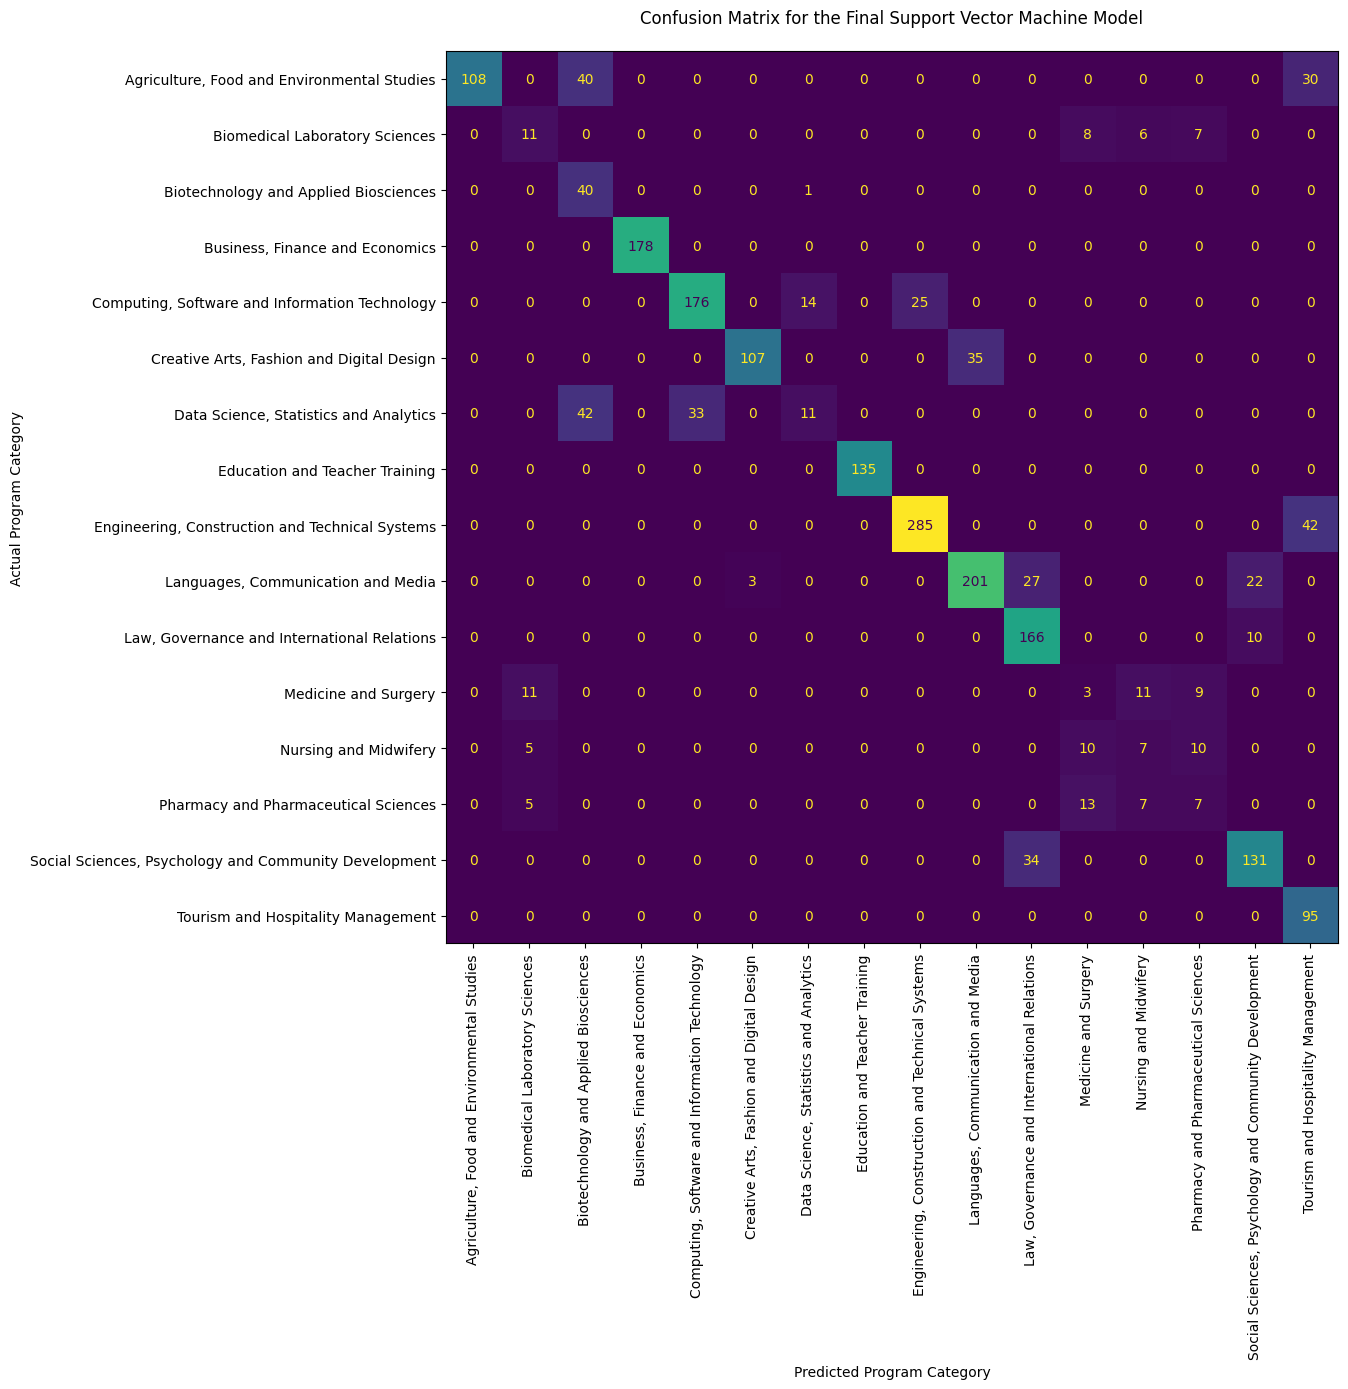

In [29]:
# Create the raw-count confusion matrix
final_confusion_matrix = confusion_matrix(
    y_test_encoded,
    y_test_pred_encoded,
    labels=range(len(label_encoder.classes_))
)

fig, ax = plt.subplots(figsize=(16, 14))

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=label_encoder.classes_
)

confusion_display.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Confusion Matrix for the Final Support Vector Machine Model",
    pad=20
)

ax.set_xlabel("Predicted Program Category")
ax.set_ylabel("Actual Program Category")

plt.tight_layout()
plt.show()

**12B. Normalized confusion matrix**

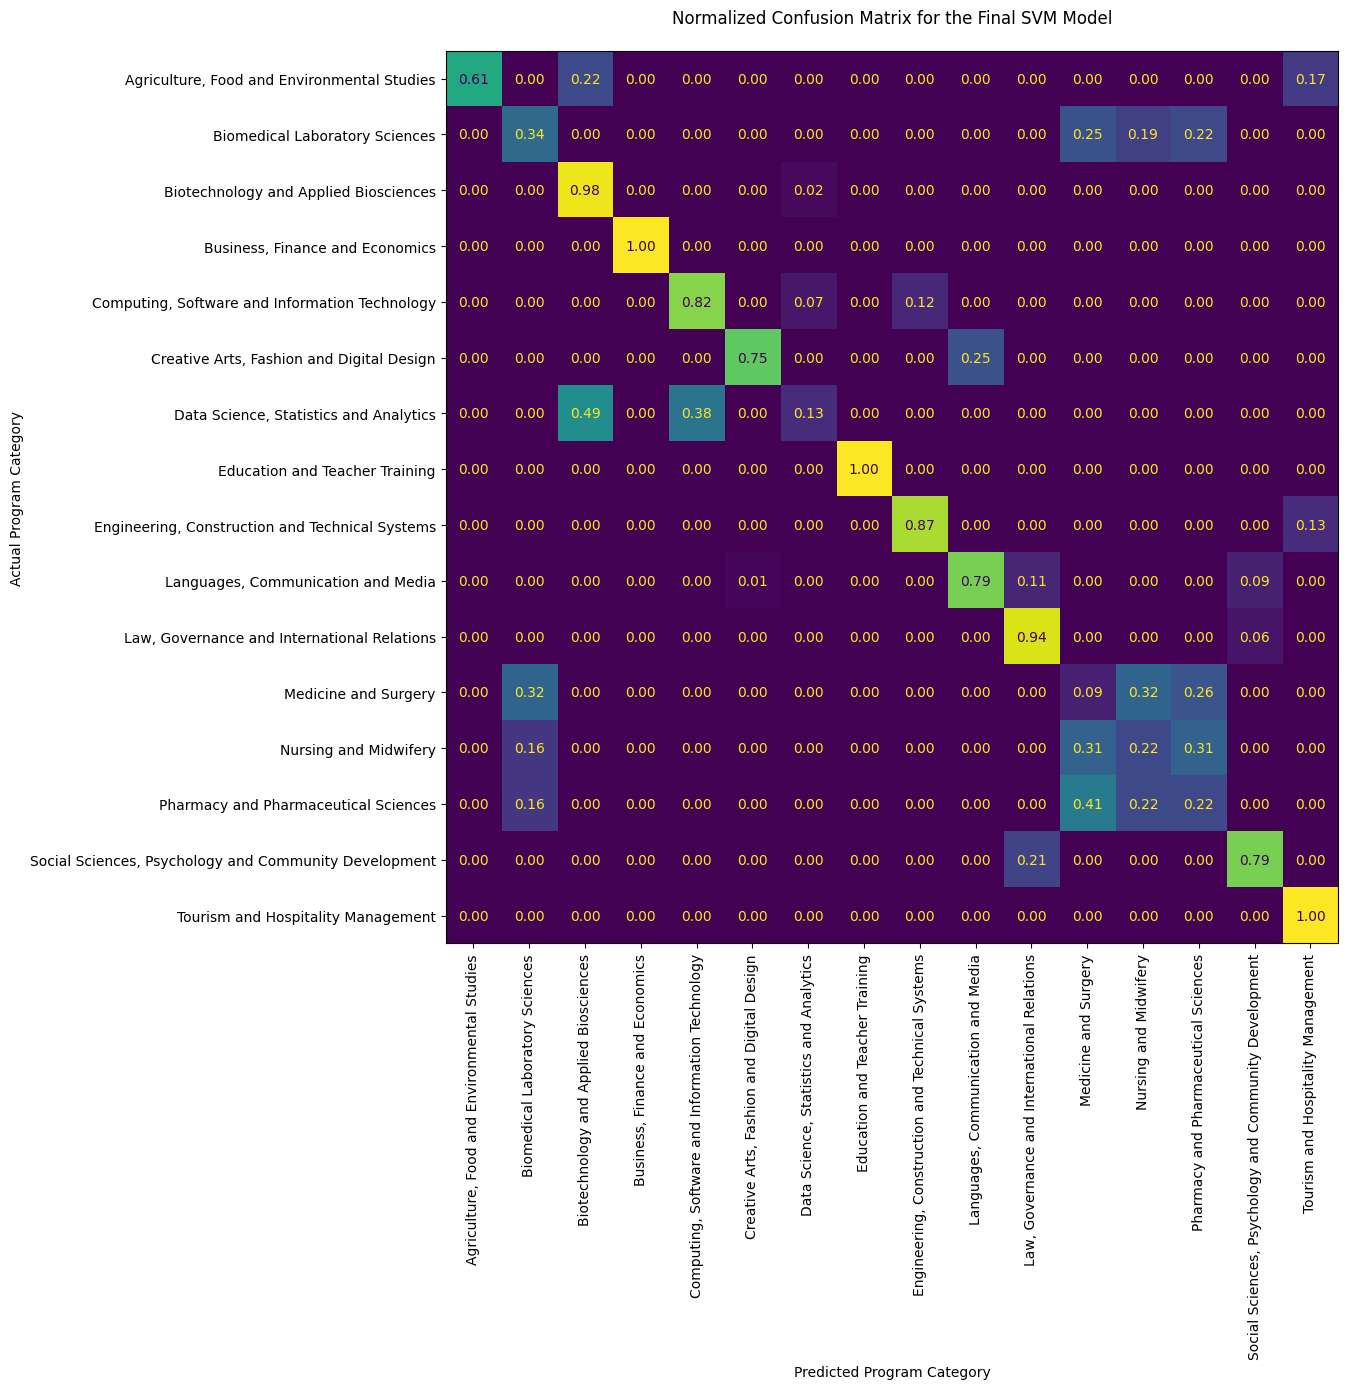

In [30]:
# Normalize by the number of actual records in each category
normalized_confusion_matrix = confusion_matrix(
    y_test_encoded,
    y_test_pred_encoded,
    labels=range(len(label_encoder.classes_)),
    normalize="true"
)

fig, ax = plt.subplots(figsize=(16, 14))

normalized_display = ConfusionMatrixDisplay(
    confusion_matrix=normalized_confusion_matrix,
    display_labels=label_encoder.classes_
)

normalized_display.plot(
    ax=ax,
    xticks_rotation=90,
    values_format=".2f",
    colorbar=False
)

ax.set_title(
    "Normalized Confusion Matrix for the Final SVM Model",
    pad=20
)

ax.set_xlabel("Predicted Program Category")
ax.set_ylabel("Actual Program Category")

plt.tight_layout()
plt.show()

**Step 12C: Identify the strongest and weakest classes**

In [31]:
# Extract results for the 16 actual program categories only
class_performance_df = classification_report_df.loc[
    label_encoder.classes_,
    ["precision", "recall", "f1-score", "support"]
].copy()

class_performance_df.index.name = "Program Category"

# Rank categories by F1-score
class_performance_ranked = class_performance_df.sort_values(
    by="f1-score",
    ascending=False
)

print("FIVE STRONGEST PROGRAM CATEGORIES")
print("-" * 50)

display(class_performance_ranked.head(5))

print("\nFIVE WEAKEST PROGRAM CATEGORIES")
print("-" * 50)

display(class_performance_ranked.tail(5).sort_values("f1-score"))

FIVE STRONGEST PROGRAM CATEGORIES
--------------------------------------------------


,precision,recall,f1-score,support
Program Category,,,,
"Business, Finance and Economics",100.00,100.00,100.00,178.0
Education and Teacher Training,100.00,100.00,100.00,135.0
"Engineering, Construction and Technical Systems",91.94,87.16,89.48,327.0
"Creative Arts, Fashion and Digital Design",97.27,75.35,84.92,142.0
"Computing, Software and Information Technology",84.21,81.86,83.02,215.0



FIVE WEAKEST PROGRAM CATEGORIES
--------------------------------------------------


,precision,recall,f1-score,support
Program Category,,,,
Medicine and Surgery,8.82,8.82,8.82,34.0
"Data Science, Statistics and Analytics",42.31,12.79,19.64,86.0
Pharmacy and Pharmaceutical Sciences,21.21,21.88,21.54,32.0
Nursing and Midwifery,22.58,21.88,22.22,32.0
Biomedical Laboratory Sciences,34.38,34.38,34.38,32.0


## 13. Analysis of Model Results

The Support Vector Machine achieved a final test accuracy of **78.31%** and a micro F1-score of **78.31%**. This means that approximately 78 out of every 100 test profiles were assigned to the correct broader academic program category.

The macro F1-score was **62.85%**, which is lower than the overall accuracy. This difference indicates that the model performs considerably better on some categories than on others. Accuracy is influenced more strongly by the larger categories, while macro F1-score gives equal importance to all 16 categories, including those with fewer records.

The strongest categories were **Business, Finance and Economics** and **Education and Teacher Training**, both achieving an F1-score of 100%. Engineering, Creative Arts, Computing, Languages, Law, and Social Sciences also achieved relatively strong performance. These categories appear to have more distinctive combinations of pathway, stream or trade, interest area, and career cluster.

The weakest performance was observed in **Medicine and Surgery**, **Data Science, Statistics and Analytics**, **Pharmacy and Pharmaceutical Sciences**, **Nursing and Midwifery**, and **Biomedical Laboratory Sciences**. These categories contain fewer test examples and share similar academic backgrounds, subjects, and career interests. For example, several health-related programs may be associated with Mathematics and Sciences, Biology, Chemistry, STEM interests, and the Medicine and Health career cluster. This overlap makes it difficult for the model to distinguish between individual health program categories using the current input features.

The proposal anticipated at least **80% accuracy** and **75% macro F1-score**. The final model achieved 78.31% accuracy and 62.85% macro F1-score. Therefore, the anticipated performance targets were not fully achieved. However, the model demonstrated useful predictive ability across several major program categories and provides a measurable baseline for future improvement.

Future improvements should include collecting more balanced real student data, adding more detailed subject-grade information, separating broad health categories using stronger eligibility features, tuning model hyperparameters, and testing alternative classification strategies.

In [32]:
!pip install -q shap

In [33]:
import shap

## 14. Explainable AI Using SHAP

SHAP is used to explain how the trained Support Vector Machine makes its recommendations.

Because the selected model is a linear multiclass classifier, SHAP explains each feature's contribution to the model's decision score for every program category.

Two levels of explanation are presented:

- **Global explanation:** identifies the student-profile features that influence the model most across multiple test profiles.
- **Local explanation:** identifies the features that supported or opposed an individual student's predicted program category.

SHAP explanations describe the trained machine-learning model itself. They are not generated by restating the student's input values.

In [35]:
# Retrieve the fitted components from the final pipeline
fitted_preprocessor = final_model_pipeline.named_steps["preprocessor"]
fitted_classifier = final_model_pipeline.named_steps["classifier"]

# Helper function for converting sparse matrices to dense arrays
def to_dense(matrix):
    if hasattr(matrix, "toarray"):
        return matrix.toarray()

    return np.asarray(matrix)


# Use a representative background sample from the development set
shap_background_profiles = X_train.sample(
    n=min(500, len(X_train)),
    random_state=RANDOM_STATE
)

# Select up to 20 test profiles from each target category
# This creates a more balanced explanation sample.
balanced_explanation_indices = []

for class_id in sorted(np.unique(y_test_encoded)):
    class_positions = np.where(
        y_test_encoded == class_id
    )[0]

    number_to_select = min(
        20,
        len(class_positions)
    )

    random_generator = np.random.RandomState(
        RANDOM_STATE + int(class_id)
    )

    selected_positions = random_generator.choice(
        class_positions,
        size=number_to_select,
        replace=False
    )

    balanced_explanation_indices.extend(
        X_test.index[selected_positions]
    )

shap_explanation_profiles = X_test.loc[
    balanced_explanation_indices
].copy()

# Transform the profiles using the fitted preprocessing pipeline
X_shap_background = to_dense(
    fitted_preprocessor.transform(
        shap_background_profiles
    )
)

X_shap_explanation = to_dense(
    fitted_preprocessor.transform(
        shap_explanation_profiles
    )
)

# Retrieve the names of all transformed features
transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

# Create the SHAP explainer for the trained LinearSVC model
shap_explainer = shap.LinearExplainer(
    fitted_classifier,
    X_shap_background
)

# Calculate SHAP values for the balanced test sample
shap_explanation = shap_explainer(
    X_shap_explanation
)

shap_values_array = np.asarray(
    shap_explanation.values
)

print("SHAP EXPLAINABILITY SUMMARY")
print("-" * 50)
print("Explained model: Support Vector Machine")
print(
    f"Background profiles: "
    f"{len(shap_background_profiles):,}"
)
print(
    f"Test profiles explained: "
    f"{len(shap_explanation_profiles):,}"
)
print(
    f"Transformed input features: "
    f"{len(transformed_feature_names)}"
)
print(
    f"SHAP values shape: "
    f"{shap_values_array.shape}"
)

SHAP EXPLAINABILITY SUMMARY
--------------------------------------------------
Explained model: Support Vector Machine
Background profiles: 500
Test profiles explained: 320
Transformed input features: 69
SHAP values shape: (320, 69, 16)


**Step 14B: Aggregate SHAP values into the original nine features**

In [36]:
# Link each encoded feature back to its original input feature
def identify_original_feature(transformed_name):
    clean_name = transformed_name.split(
        "__",
        1
    )[-1]

    # Check longer names first
    for original_feature in sorted(
        FEATURE_COLUMNS,
        key=len,
        reverse=True
    ):
        if (
            clean_name == original_feature
            or clean_name.startswith(
                f"{original_feature}_"
            )
        ):
            return original_feature

    return clean_name


original_feature_groups = {}

for feature_index, transformed_name in enumerate(
    transformed_feature_names
):
    original_feature = identify_original_feature(
        transformed_name
    )

    original_feature_groups.setdefault(
        original_feature,
        []
    ).append(feature_index)


global_shap_results = []

for original_feature in FEATURE_COLUMNS:
    encoded_indices = original_feature_groups.get(
        original_feature,
        []
    )

    if not encoded_indices:
        continue

    if shap_values_array.ndim == 3:
        # Dimensions:
        # profiles × transformed features × classes
        grouped_contributions = (
            shap_values_array[
                :,
                encoded_indices,
                :
            ].sum(axis=1)
        )

    elif shap_values_array.ndim == 2:
        # Used if SHAP returns a two-dimensional result
        grouped_contributions = (
            shap_values_array[
                :,
                encoded_indices
            ].sum(axis=1)
        )

    else:
        raise ValueError(
            "Unexpected SHAP output dimensions: "
            f"{shap_values_array.ndim}"
        )

    mean_absolute_contribution = np.mean(
        np.abs(grouped_contributions)
    )

    global_shap_results.append({
        "Student Profile Feature": original_feature,
        "Mean Absolute SHAP Value":
            mean_absolute_contribution
    })


global_shap_importance_df = pd.DataFrame(
    global_shap_results
)

global_shap_importance_df[
    "Relative Importance (%)"
] = (
    global_shap_importance_df[
        "Mean Absolute SHAP Value"
    ]
    / global_shap_importance_df[
        "Mean Absolute SHAP Value"
    ].sum()
    * 100
)

global_shap_importance_df = (
    global_shap_importance_df
    .sort_values(
        by="Mean Absolute SHAP Value",
        ascending=False
    )
    .reset_index(drop=True)
)

global_shap_importance_df[
    "Mean Absolute SHAP Value"
] = global_shap_importance_df[
    "Mean Absolute SHAP Value"
].round(4)

global_shap_importance_df[
    "Relative Importance (%)"
] = global_shap_importance_df[
    "Relative Importance (%)"
].round(2)

print("GLOBAL SHAP FEATURE IMPORTANCE")
print("-" * 50)

display(global_shap_importance_df)

GLOBAL SHAP FEATURE IMPORTANCE
--------------------------------------------------


,Student Profile Feature,Mean Absolute SHAP Value,Relative Importance (%)
0,CareerCluster,0.2642,45.04
1,Stream_or_Trade,0.0620,10.56
2,EducationType,0.0562,9.58
3,BestSubject,0.0550,9.38
4,Pathway,0.0380,6.48
5,InterestArea,0.0380,6.48
6,AverageScoreRange,0.0287,4.90
7,WeakestSubject,0.0250,4.25
8,DigitalSkillLevel,0.0195,3.32


**Step 14C: Visualise the global SHAP results**

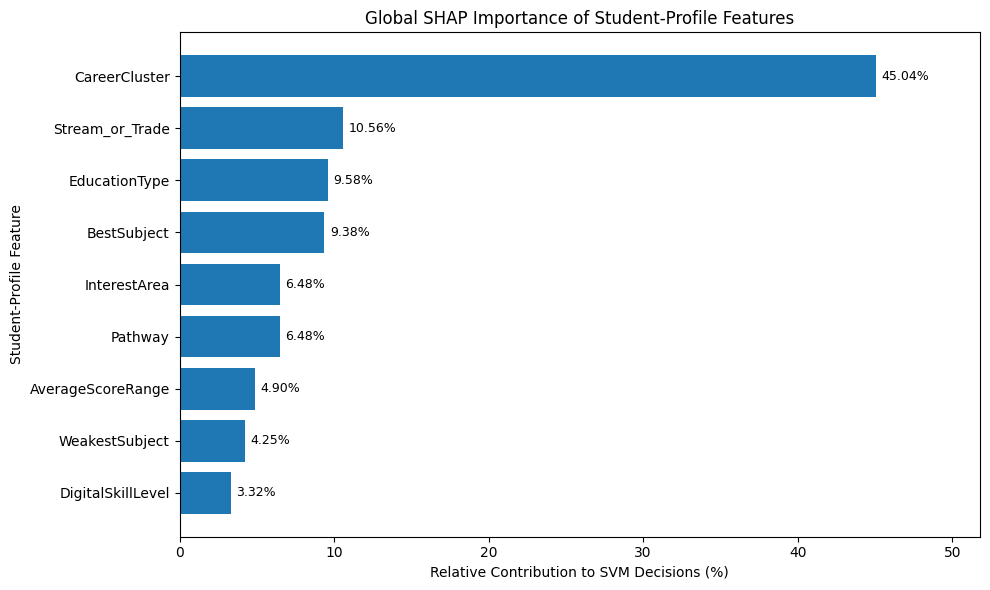

In [37]:
global_shap_plot_df = (
    global_shap_importance_df
    .sort_values(
        by="Relative Importance (%)",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    global_shap_plot_df[
        "Student Profile Feature"
    ],
    global_shap_plot_df[
        "Relative Importance (%)"
    ]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in global_shap_plot_df[
            "Relative Importance (%)"
        ]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Global SHAP Importance of Student-Profile Features"
)

ax.set_xlabel(
    "Relative Contribution to SVM Decisions (%)"
)

ax.set_ylabel(
    "Student-Profile Feature"
)

ax.set_xlim(
    0,
    global_shap_plot_df[
        "Relative Importance (%)"
    ].max() * 1.15
)

plt.tight_layout()
plt.show()

**Step 14D: Correct the grouped global SHAP importance**

In [38]:
# Correctly aggregate the absolute contributions of encoded columns
# back into the original nine student-profile features

global_shap_results = []

for original_feature in FEATURE_COLUMNS:

    encoded_indices = original_feature_groups.get(
        original_feature,
        []
    )

    if not encoded_indices:
        continue

    if shap_values_array.ndim == 3:
        # profiles × transformed features × program classes
        feature_contributions = np.abs(
            shap_values_array[
                :,
                encoded_indices,
                :
            ]
        )

        # Sum the encoded columns belonging to the original feature,
        # then average across profiles and classes
        mean_absolute_contribution = (
            feature_contributions
            .sum(axis=1)
            .mean()
        )

    elif shap_values_array.ndim == 2:
        feature_contributions = np.abs(
            shap_values_array[
                :,
                encoded_indices
            ]
        )

        mean_absolute_contribution = (
            feature_contributions
            .sum(axis=1)
            .mean()
        )

    else:
        raise ValueError(
            "Unexpected SHAP output dimensions: "
            f"{shap_values_array.ndim}"
        )

    global_shap_results.append({
        "Student Profile Feature": original_feature,
        "Mean Absolute SHAP Value":
            mean_absolute_contribution
    })


global_shap_importance_df = pd.DataFrame(
    global_shap_results
)

global_shap_importance_df[
    "Relative Importance (%)"
] = (
    global_shap_importance_df[
        "Mean Absolute SHAP Value"
    ]
    / global_shap_importance_df[
        "Mean Absolute SHAP Value"
    ].sum()
    * 100
)

global_shap_importance_df = (
    global_shap_importance_df
    .sort_values(
        by="Mean Absolute SHAP Value",
        ascending=False
    )
    .reset_index(drop=True)
)

global_shap_importance_df[
    "Mean Absolute SHAP Value"
] = (
    global_shap_importance_df[
        "Mean Absolute SHAP Value"
    ].round(4)
)

global_shap_importance_df[
    "Relative Importance (%)"
] = (
    global_shap_importance_df[
        "Relative Importance (%)"
    ].round(2)
)

print("CORRECTED GLOBAL SHAP FEATURE IMPORTANCE")
print("-" * 55)

display(global_shap_importance_df)

CORRECTED GLOBAL SHAP FEATURE IMPORTANCE
-------------------------------------------------------


,Student Profile Feature,Mean Absolute SHAP Value,Relative Importance (%)
0,CareerCluster,0.4372,33.76
1,InterestArea,0.1586,12.25
2,Pathway,0.1586,12.25
3,EducationType,0.1508,11.65
4,Stream_or_Trade,0.1497,11.57
5,BestSubject,0.1125,8.69
6,WeakestSubject,0.0792,6.12
7,AverageScoreRange,0.0287,2.22
8,DigitalSkillLevel,0.0195,1.51


## 15. Local SHAP Explanation for an Individual Recommendation

A local SHAP explanation shows how a particular student's profile influenced the predicted program category.

Positive contributions increase the model's decision score for the predicted category, while negative contributions reduce it. The explanation represents the reasoning of the trained Support Vector Machine rather than a predefined text template.

In [41]:
def explain_student_prediction(
    student_profile,
    model_pipeline,
    label_encoder,
    shap_explainer,
    transformed_feature_names,
    original_feature_groups
):
    """
    Predict a program category and explain the prediction by
    aggregating SHAP values into the original student-profile features.
    """

    # Create a correctly ordered student-profile DataFrame
    profile_df = pd.DataFrame(
        [student_profile]
    )[FEATURE_COLUMNS]

    fitted_preprocessor = (
        model_pipeline.named_steps["preprocessor"]
    )

    # Generate the predicted class
    predicted_class_id = int(
        model_pipeline.predict(profile_df)[0]
    )

    predicted_category = (
        label_encoder.inverse_transform(
            [predicted_class_id]
        )[0]
    )

    # Obtain multiclass SVM decision scores
    decision_scores = (
        model_pipeline.decision_function(profile_df)[0]
    )

    # Rank the three strongest model recommendations
    top_class_ids = np.argsort(
        decision_scores
    )[::-1][:3]

    top_recommendations_df = pd.DataFrame({
        "Rank": range(1, len(top_class_ids) + 1),
        "Program Category": label_encoder.inverse_transform(
            top_class_ids
        ),
        "SVM Decision Score": decision_scores[top_class_ids]
    })

    top_recommendations_df[
        "SVM Decision Score"
    ] = top_recommendations_df[
        "SVM Decision Score"
    ].round(4)

    # Transform the student profile
    transformed_profile = to_dense(
        fitted_preprocessor.transform(profile_df)
    )

    # Calculate SHAP values
    student_shap_explanation = shap_explainer(
        transformed_profile
    )

    student_shap_values = np.asarray(
        student_shap_explanation.values
    )

    # Select SHAP values for the predicted program category
    if student_shap_values.ndim == 3:
        predicted_class_shap_values = (
            student_shap_values[
                0,
                :,
                predicted_class_id
            ]
        )
    elif student_shap_values.ndim == 2:
        predicted_class_shap_values = (
            student_shap_values[0]
        )
    else:
        raise ValueError(
            "Unexpected SHAP output dimensions: "
            f"{student_shap_values.ndim}"
        )

    # Aggregate encoded columns into the nine original features
    grouped_explanation_rows = []

    for original_feature in FEATURE_COLUMNS:

        encoded_indices = original_feature_groups.get(
            original_feature,
            []
        )

        if not encoded_indices:
            continue

        grouped_contribution = (
            predicted_class_shap_values[
                encoded_indices
            ].sum()
        )

        grouped_explanation_rows.append({
            "Student Profile Feature": original_feature,
            "Student Input": student_profile[
                original_feature
            ],
            "SHAP Contribution": grouped_contribution,
            "Absolute Contribution": abs(
                grouped_contribution
            )
        })

    grouped_explanation_df = pd.DataFrame(
        grouped_explanation_rows
    )

    grouped_explanation_df[
        "Effect on Recommendation"
    ] = np.where(
        grouped_explanation_df[
            "SHAP Contribution"
        ] > 0,
        "Supported recommendation",
        "Opposed recommendation"
    )

    grouped_explanation_df = (
        grouped_explanation_df
        .sort_values(
            by="Absolute Contribution",
            ascending=False
        )
        .reset_index(drop=True)
    )

    grouped_explanation_df[
        "SHAP Contribution"
    ] = grouped_explanation_df[
        "SHAP Contribution"
    ].round(4)

    print("INDIVIDUAL MODEL EXPLANATION")
    print("-" * 60)
    print(
        f"Predicted program category: "
        f"{predicted_category}"
    )

    print("\nStudent profile:")
    display(profile_df)

    print("\nTop three model recommendations:")
    display(top_recommendations_df)

    print("\nFeature-level SHAP explanation:")
    display(
        grouped_explanation_df[
            [
                "Student Profile Feature",
                "Student Input",
                "SHAP Contribution",
                "Effect on Recommendation"
            ]
        ]
    )

    return {
        "predicted_category": predicted_category,
        "top_recommendations": top_recommendations_df,
        "feature_explanation": grouped_explanation_df
    }

In [44]:
general_education_profile = {
    "EducationType": "General Education",
    "Pathway": "Mathematics and Sciences",
    "Stream_or_Trade": "Stream 1",
    "BestSubject": "Biology",
    "WeakestSubject": "History",
    "InterestArea": "STEM Fields",
    "AverageScoreRange": "80–89%",
    "DigitalSkillLevel": "Intermediate",
    "CareerCluster": "Medicine & Health"
}

general_explanation_result = explain_student_prediction(
    student_profile=general_education_profile,
    model_pipeline=final_model_pipeline,
    label_encoder=label_encoder,
    shap_explainer=shap_explainer,
    transformed_feature_names=transformed_feature_names,
    original_feature_groups=original_feature_groups
)

INDIVIDUAL MODEL EXPLANATION
------------------------------------------------------------
Predicted program category: Medicine and Surgery

Student profile:


,EducationType,Pathway,Stream_or_Trade,BestSubject,WeakestSubject,InterestArea,AverageScoreRange,DigitalSkillLevel,CareerCluster
0,General Education,Mathematics and Sciences,Stream 1,Biology,History,STEM Fields,80–89%,Intermediate,Medicine & Health



Top three model recommendations:


,Rank,Program Category,SVM Decision Score
0,1,Medicine and Surgery,0.2354
1,2,Nursing and Midwifery,0.1734
2,3,Pharmacy and Pharmaceutical Sciences,0.1139



Feature-level SHAP explanation:


,Student Profile Feature,Student Input,SHAP Contribution,Effect on Recommendation
0,CareerCluster,Medicine & Health,1.2791,Supported recommendation
1,WeakestSubject,History,0.0991,Supported recommendation
2,Stream_or_Trade,Stream 1,0.0916,Supported recommendation
3,EducationType,General Education,-0.0519,Opposed recommendation
4,BestSubject,Biology,-0.0305,Opposed recommendation
5,AverageScoreRange,80–89%,-0.0049,Opposed recommendation
6,Pathway,Mathematics and Sciences,-0.0023,Opposed recommendation
7,InterestArea,STEM Fields,-0.0023,Opposed recommendation
8,DigitalSkillLevel,Intermediate,-0.0009,Opposed recommendation


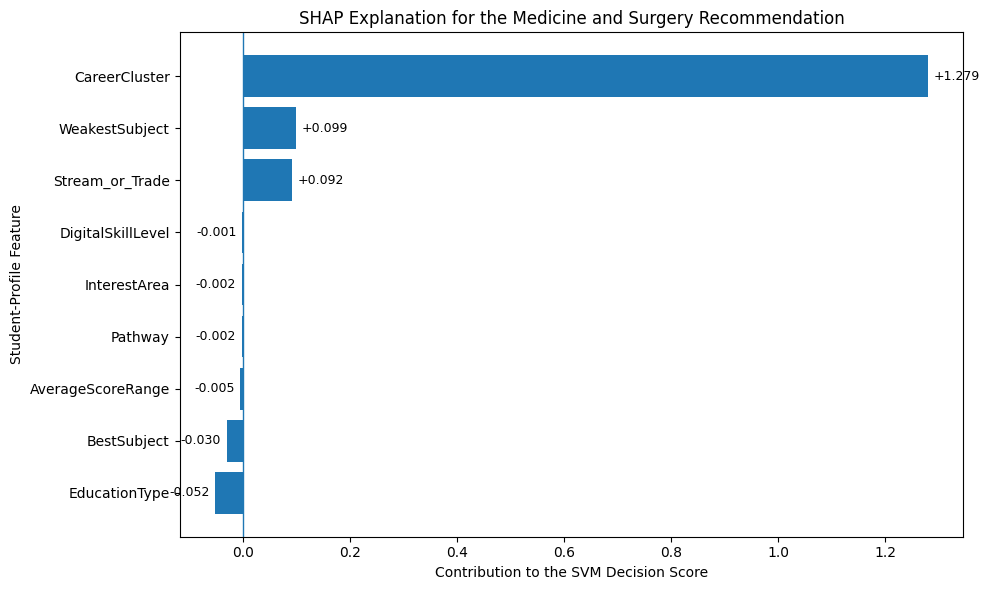

In [45]:
local_explanation_plot_df = (
    general_explanation_result[
        "feature_explanation"
    ]
    .sort_values(
        by="SHAP Contribution",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    local_explanation_plot_df[
        "Student Profile Feature"
    ],
    local_explanation_plot_df[
        "SHAP Contribution"
    ]
)

ax.axvline(
    x=0,
    linewidth=1
)

ax.bar_label(
    bars,
    labels=[
        f"{value:+.3f}"
        for value in local_explanation_plot_df[
            "SHAP Contribution"
        ]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    "SHAP Explanation for the Medicine and Surgery Recommendation"
)

ax.set_xlabel(
    "Contribution to the SVM Decision Score"
)

ax.set_ylabel(
    "Student-Profile Feature"
)

plt.tight_layout()
plt.show()

### Local Explanation Interpretation

For the selected General Education profile, the model recommended **Medicine and Surgery**. The next two highest-ranked categories were **Nursing and Midwifery** and **Pharmacy and Pharmaceutical Sciences**, showing that the model consistently associated the profile with health-related study areas.

The strongest positive influence was the student's **Medicine and Health career cluster**. Stream 1 and the weakest-subject profile also provided smaller positive contributions. Other inputs made small negative contributions relative to the SHAP background sample.

A negative SHAP value does not mean that a feature is academically unsuitable. It means that the feature reduced the model's decision score relative to the model's baseline after the other profile variables were considered. The explanation also shows that the model relies strongly on the career cluster, indicating that future versions should include more detailed academic performance features and reduce dependence on a single career-preference variable.

## 16. Subgroup and Edge-Case Testing

The final model is evaluated separately for General Education and TVET students. This confirms that both student populations are processed through the same trained machine-learning pipeline.

A lower-score edge case is also tested using the `50–59%` score range. This range is supported by the preprocessing pipeline but was not represented in the training dataset. Its output is therefore treated as an exploratory recommendation rather than a validated performance result.

**16A. General Education and TVET subgroup results**

In [46]:
# Combine test profiles, actual categories, and predictions
test_evaluation_df = X_test.reset_index(drop=True).copy()

test_evaluation_df["ActualEncoded"] = y_test_encoded
test_evaluation_df["PredictedEncoded"] = y_test_pred_encoded

test_evaluation_df["ActualCategory"] = (
    label_encoder.inverse_transform(y_test_encoded)
)

test_evaluation_df["PredictedCategory"] = (
    label_encoder.inverse_transform(y_test_pred_encoded)
)


def calculate_subgroup_metrics(group_name, mask):
    """Calculate model performance for a selected student subgroup."""

    subgroup_true = test_evaluation_df.loc[
        mask,
        "ActualEncoded"
    ]

    subgroup_predicted = test_evaluation_df.loc[
        mask,
        "PredictedEncoded"
    ]

    return {
        "Student Group": group_name,
        "Test Records": len(subgroup_true),
        "Correct Predictions": int(
            (subgroup_true == subgroup_predicted).sum()
        ),
        "Accuracy": accuracy_score(
            subgroup_true,
            subgroup_predicted
        ),
        "Macro Precision": precision_score(
            subgroup_true,
            subgroup_predicted,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            subgroup_true,
            subgroup_predicted,
            average="macro",
            zero_division=0
        ),
        "Macro F1-score": f1_score(
            subgroup_true,
            subgroup_predicted,
            average="macro",
            zero_division=0
        )
    }


overall_mask = pd.Series(
    True,
    index=test_evaluation_df.index
)

general_education_mask = (
    test_evaluation_df["EducationType"]
    == "General Education"
)

tvet_mask = (
    test_evaluation_df["EducationType"]
    == "TVET"
)

subgroup_results = [
    calculate_subgroup_metrics(
        "Overall Test Set",
        overall_mask
    ),
    calculate_subgroup_metrics(
        "General Education",
        general_education_mask
    ),
    calculate_subgroup_metrics(
        "TVET",
        tvet_mask
    )
]

subgroup_results_df = pd.DataFrame(
    subgroup_results
)

metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1-score"
]

for column in metric_columns:
    subgroup_results_df[column] = (
        subgroup_results_df[column] * 100
    ).round(2)

print("SUBGROUP PERFORMANCE RESULTS")
print("-" * 55)

display(subgroup_results_df)

SUBGROUP PERFORMANCE RESULTS
-------------------------------------------------------


,Student Group,Test Records,Correct Predictions,Accuracy,Macro Precision,Macro Recall,Macro F1-score
0,Overall Test Set,2121,1661,78.31,64.44,65.97,62.85
1,General Education,1503,1043,69.39,50.61,55.39,49.94
2,TVET,618,618,100.00,100.00,100.00,100.00


**16B. Generate a genuine TVET model explanation**

In [47]:
# Find a correctly classified TVET example
correct_tvet_profiles = test_evaluation_df[
    (test_evaluation_df["EducationType"] == "TVET")
    & (
        test_evaluation_df["ActualEncoded"]
        == test_evaluation_df["PredictedEncoded"]
    )
]

if correct_tvet_profiles.empty:
    raise ValueError(
        "No correctly classified TVET profile was found "
        "in the final test set."
    )

selected_tvet_record = correct_tvet_profiles.iloc[0]

tvet_profile = {
    feature: selected_tvet_record[feature]
    for feature in FEATURE_COLUMNS
}

print("Selected TVET test example")
print("-" * 55)
print(
    "Actual category:",
    selected_tvet_record["ActualCategory"]
)

tvet_explanation_result = explain_student_prediction(
    student_profile=tvet_profile,
    model_pipeline=final_model_pipeline,
    label_encoder=label_encoder,
    shap_explainer=shap_explainer,
    transformed_feature_names=transformed_feature_names,
    original_feature_groups=original_feature_groups
)

Selected TVET test example
-------------------------------------------------------
Actual category: Creative Arts, Fashion and Digital Design
INDIVIDUAL MODEL EXPLANATION
------------------------------------------------------------
Predicted program category: Creative Arts, Fashion and Digital Design

Student profile:


,EducationType,Pathway,Stream_or_Trade,BestSubject,WeakestSubject,InterestArea,AverageScoreRange,DigitalSkillLevel,CareerCluster
0,TVET,TVET Route,Tailoring / Fashion Design,Practical Workshop / Execution,Academic Theory,Technical Trades,80–89%,Intermediate,"Business, Art, and Craft"



Top three model recommendations:


,Rank,Program Category,SVM Decision Score
0,1,"Creative Arts, Fashion and Digital Design",1.0431
1,2,"Business, Finance and Economics",-0.9982
2,3,Education and Teacher Training,-1.0000



Feature-level SHAP explanation:


,Student Profile Feature,Student Input,SHAP Contribution,Effect on Recommendation
0,Stream_or_Trade,Tailoring / Fashion Design,1.3390,Supported recommendation
1,CareerCluster,"Business, Art, and Craft",0.5015,Supported recommendation
2,EducationType,TVET,0.1677,Supported recommendation
3,BestSubject,Practical Workshop / Execution,-0.0348,Opposed recommendation
4,WeakestSubject,Academic Theory,0.0213,Supported recommendation
5,Pathway,TVET Route,0.0203,Supported recommendation
6,InterestArea,Technical Trades,0.0203,Supported recommendation
7,AverageScoreRange,80–89%,0.0081,Supported recommendation
8,DigitalSkillLevel,Intermediate,0.0001,Supported recommendation


**16C. Test the unseen 50–59% score range**

In [48]:
# Create a lower-score variation of the General Education profile
lower_score_profile = general_education_profile.copy()

lower_score_profile["AverageScoreRange"] = "50–59%"

lower_score_df = pd.DataFrame(
    [lower_score_profile]
)[FEATURE_COLUMNS]

lower_score_prediction_id = int(
    final_model_pipeline.predict(
        lower_score_df
    )[0]
)

lower_score_prediction = (
    label_encoder.inverse_transform(
        [lower_score_prediction_id]
    )[0]
)

lower_score_decision_scores = (
    final_model_pipeline.decision_function(
        lower_score_df
    )[0]
)

lower_score_top_ids = np.argsort(
    lower_score_decision_scores
)[::-1][:3]

lower_score_top_recommendations = pd.DataFrame({
    "Rank": [1, 2, 3],
    "Program Category": (
        label_encoder.inverse_transform(
            lower_score_top_ids
        )
    ),
    "SVM Decision Score": (
        lower_score_decision_scores[
            lower_score_top_ids
        ].round(4)
    )
})

print("LOWER-SCORE EDGE-CASE TEST")
print("-" * 55)
print("Input score range: 50–59%")
print(
    f"Predicted program category: "
    f"{lower_score_prediction}"
)
print("Profile processed successfully: Yes")

display(lower_score_top_recommendations)

LOWER-SCORE EDGE-CASE TEST
-------------------------------------------------------
Input score range: 50–59%
Predicted program category: Medicine and Surgery
Profile processed successfully: Yes


,Rank,Program Category,SVM Decision Score
0,1,Medicine and Surgery,0.2866
1,2,Biomedical Laboratory Sciences,0.1608
2,3,Nursing and Midwifery,0.0504


## 17. Interpretation of Subgroup and Edge-Case Results

The final model achieved an accuracy of **69.39%** and a macro F1-score of **49.94%** for General Education students. These results are substantially lower than the overall model performance, showing that most classification errors occur within the General Education population.

The TVET subgroup achieved 100% accuracy and macro F1-score. This result should be interpreted cautiously. The synthetic dataset contains highly consistent relationships between TVET trades and recommended program categories. For example, Tailoring and Fashion Design strongly corresponds to Creative Arts, Fashion and Digital Design. The model may therefore be learning nearly deterministic trade-to-program relationships that may not fully reflect the diversity of real TVET learners.

The TVET SHAP explanation confirmed that `Stream_or_Trade` was the strongest factor in the selected recommendation, followed by career cluster and education type. This demonstrates that TVET profiles are processed through the trained machine-learning model rather than a separate hardcoded output dictionary.

The lower-score edge case was successfully processed using the previously unseen `50–59%` category. However, it was still assigned to Medicine and Surgery because the Medicine and Health career cluster strongly influenced the model. This result shows that machine-learning predictions must be reviewed through an eligibility-validation layer before being presented as final academic guidance.

The hybrid system will therefore use the trained model as the primary recommendation engine and apply rules afterward to:

- identify potential academic-readiness concerns;
- recommend bridge courses;
- provide warnings where profile evidence is weak;
- suggest alternative program categories without replacing the model prediction.

In [49]:
from dataclasses import dataclass, asdict
from typing import Dict, List, Any

## 18. ML-First Hybrid Recommendation System

The trained Support Vector Machine remains the primary prediction engine. It ranks the learner profile across 16 broad academic program categories.

The deployed application then adds a transparent academic-guidance layer:

1. Receive and validate the learner profile.
2. Use the trained SVM to rank the broad academic categories.
3. Apply pathway, stream, and TVET-trade eligibility checks so that an incompatible preference does not become the final guidance.
4. Refine the highest eligible broad category into a specific program direction.
5. Map the selected program to bridge courses and a related alternative pathway.
6. Use SHAP to explain the SVM broad-category decision in learner-friendly language.
7. Present the result as advisory guidance rather than an official admission decision.

The guidance rules do not replace the trained model. They constrain and refine the model-ranked result for academic consistency, while SHAP continues to explain the underlying SVM decision.


In [50]:
@dataclass
class StudentProfile:
    EducationType: str
    Pathway: str
    Stream_or_Trade: str
    BestSubject: str
    WeakestSubject: str
    InterestArea: str
    AverageScoreRange: str
    DigitalSkillLevel: str
    CareerCluster: str

    def to_dataframe(self) -> pd.DataFrame:
        """Convert the profile into the model's expected structure."""
        return pd.DataFrame([asdict(self)])[FEATURE_COLUMNS]

In [51]:
BRIDGE_COURSE_MAPPING = {
    "Medicine and Surgery": [
        "Human Biology Foundations",
        "Chemistry Foundations",
        "Scientific Study Skills"
    ],

    "Nursing and Midwifery": [
        "Human Biology Foundations",
        "Health Communication",
        "Patient Care Fundamentals"
    ],

    "Pharmacy and Pharmaceutical Sciences": [
        "Chemistry Foundations",
        "Human Biology",
        "Mathematics for Health Sciences"
    ],

    "Biomedical Laboratory Sciences": [
        "Biology Laboratory Skills",
        "Chemistry Foundations",
        "Scientific Data Interpretation"
    ],

    "Biotechnology and Applied Biosciences": [
        "Biology Foundations",
        "Laboratory Methods",
        "Applied Chemistry"
    ],

    "Data Science, Statistics and Analytics": [
        "Mathematics for Data",
        "Statistics Foundations",
        "Python, Excel and SQL Basics"
    ],

    "Computing, Software and Information Technology": [
        "Programming Foundations",
        "Digital Problem Solving",
        "Version Control and Collaboration"
    ],

    "Engineering, Construction and Technical Systems": [
        "Mathematics and Physics Foundations",
        "Technical Drawing",
        "Engineering Study Skills"
    ],

    "Business, Finance and Economics": [
        "Business Mathematics",
        "Accounting Principles",
        "Financial Literacy"
    ],

    "Law, Governance and International Relations": [
        "Academic Writing",
        "Critical Thinking",
        "Governance and Legal Foundations"
    ],

    "Social Sciences, Psychology and Community Development": [
        "Research Methods",
        "Academic Writing",
        "Social Science Foundations"
    ],

    "Education and Teacher Training": [
        "Communication for Teaching",
        "Introduction to Pedagogy",
        "Academic Writing"
    ],

    "Languages, Communication and Media": [
        "Academic Writing",
        "Communication Skills",
        "Language and Media Literacy"
    ],

    "Tourism and Hospitality Management": [
        "Hospitality Communication",
        "Customer Service",
        "Food Safety and Tourism Foundations"
    ],

    "Agriculture, Food and Environmental Studies": [
        "Environmental Science Foundations",
        "Applied Biology",
        "Agricultural Data Skills"
    ],

    "Creative Arts, Fashion and Digital Design": [
        "Design Foundations",
        "Digital Creativity",
        "Portfolio Development"
    ]
}

In [52]:
class AcademicPathwayRecommender:
    """
    ML-first academic recommendation system.

    The trained model generates the recommendation.
    Rules are used only for readiness validation,
    bridge-course guidance, and responsible-use warnings.
    """

    def __init__(
        self,
        model_pipeline,
        label_encoder,
        shap_explainer,
        original_feature_groups
    ):
        self.model_pipeline = model_pipeline
        self.label_encoder = label_encoder
        self.shap_explainer = shap_explainer
        self.original_feature_groups = original_feature_groups

    def predict_top_categories(
        self,
        profile: StudentProfile,
        top_n: int = 3
    ) -> pd.DataFrame:
        """Return the model's top-ranked program categories."""

        profile_df = profile.to_dataframe()

        decision_scores = self.model_pipeline.decision_function(
            profile_df
        )[0]

        top_class_ids = np.argsort(
            decision_scores
        )[::-1][:top_n]

        return pd.DataFrame({
            "Rank": range(1, top_n + 1),
            "Program Category":
                self.label_encoder.inverse_transform(
                    top_class_ids
                ),
            "SVM Decision Score":
                decision_scores[top_class_ids].round(4)
        })

    def validate_readiness(
        self,
        profile: StudentProfile,
        predicted_category: str
    ) -> Dict[str, Any]:
        """
        Review academic readiness without replacing
        the machine-learning prediction.
        """

        warnings_list = []
        readiness_status = "Profile appears broadly aligned"

        lower_score_ranges = {
            "50–59%",
            "60–69%"
        }

        health_categories = {
            "Medicine and Surgery",
            "Nursing and Midwifery",
            "Pharmacy and Pharmaceutical Sciences",
            "Biomedical Laboratory Sciences",
            "Biotechnology and Applied Biosciences"
        }

        quantitative_categories = {
            "Data Science, Statistics and Analytics",
            "Computing, Software and Information Technology",
            "Engineering, Construction and Technical Systems"
        }

        if profile.AverageScoreRange in lower_score_ranges:
            warnings_list.append(
                "The score range indicates that additional "
                "academic preparation may be beneficial."
            )

        if predicted_category in health_categories:
            if profile.Pathway != "Mathematics and Sciences":
                warnings_list.append(
                    "The predicted health category may require "
                    "stronger science preparation."
                )

            if profile.BestSubject not in {
                "Biology",
                "Chemistry",
                "Physics"
            }:
                warnings_list.append(
                    "The strongest subject does not directly "
                    "match the usual science foundation for "
                    "health-related study."
                )

        if predicted_category in quantitative_categories:
            if profile.BestSubject not in {
                "Mathematics",
                "Physics",
                "Computer Science / ICT",
                "Practical Workshop / Execution"
            }:
                warnings_list.append(
                    "Additional mathematics, computing, or "
                    "technical preparation may be needed."
                )

        if warnings_list:
            readiness_status = (
                "Recommendation requires additional preparation "
                "or advisor review"
            )

        return {
            "Readiness Status": readiness_status,
            "Warnings": warnings_list
        }

    def recommend_bridge_courses(
        self,
        predicted_category: str
    ) -> List[str]:
        """Return bridge courses for the predicted category."""

        return BRIDGE_COURSE_MAPPING.get(
            predicted_category,
            [
                "Academic Writing",
                "Digital Literacy",
                "Study Skills"
            ]
        )

    def recommend(
        self,
        profile: StudentProfile
    ) -> Dict[str, Any]:
        """Generate the complete ML-first recommendation."""

        top_categories = self.predict_top_categories(
            profile=profile,
            top_n=3
        )

        predicted_category = top_categories.loc[
            0,
            "Program Category"
        ]

        readiness_review = self.validate_readiness(
            profile=profile,
            predicted_category=predicted_category
        )

        bridge_courses = self.recommend_bridge_courses(
            predicted_category
        )

        alternative_category = top_categories.loc[
            1,
            "Program Category"
        ]

        return {
            "Student Profile": asdict(profile),
            "Primary ML Recommendation": predicted_category,
            "Top Recommendations": top_categories,
            "Readiness Review": readiness_review,
            "Recommended Bridge Courses": bridge_courses,
            "Alternative Program Category": alternative_category,
            "Recommendation Source":
                "Trained Support Vector Machine",
            "Disclaimer": (
                "This is a decision-support recommendation and "
                "does not replace official admission requirements "
                "or professional academic counselling."
            )
        }

In [53]:
academic_recommender = AcademicPathwayRecommender(
    model_pipeline=final_model_pipeline,
    label_encoder=label_encoder,
    shap_explainer=shap_explainer,
    original_feature_groups=original_feature_groups
)

print("ML-first hybrid recommender created successfully.")

ML-first hybrid recommender created successfully.


In [54]:
# Validate that every model category has a bridge-course mapping
model_categories = set(label_encoder.classes_)
bridge_mapping_categories = set(BRIDGE_COURSE_MAPPING.keys())

missing_bridge_mappings = sorted(
    model_categories - bridge_mapping_categories
)

unused_bridge_mappings = sorted(
    bridge_mapping_categories - model_categories
)

print("BRIDGE-COURSE MAPPING VALIDATION")
print("-" * 55)
print(f"Model program categories: {len(model_categories)}")
print(
    f"Categories with bridge-course mappings: "
    f"{len(bridge_mapping_categories)}"
)
print(f"Missing bridge-course mappings: {missing_bridge_mappings}")
print(f"Unused bridge-course mappings: {unused_bridge_mappings}")

if not missing_bridge_mappings:
    print("\nAll predicted program categories are covered.")

BRIDGE-COURSE MAPPING VALIDATION
-------------------------------------------------------
Model program categories: 16
Categories with bridge-course mappings: 16
Missing bridge-course mappings: []
Unused bridge-course mappings: []

All predicted program categories are covered.


In [55]:
lower_score_student = StudentProfile(
    EducationType="General Education",
    Pathway="Mathematics and Sciences",
    Stream_or_Trade="Stream 1",
    BestSubject="Biology",
    WeakestSubject="History",
    InterestArea="STEM Fields",
    AverageScoreRange="50–59%",
    DigitalSkillLevel="Intermediate",
    CareerCluster="Medicine & Health"
)

lower_score_result = academic_recommender.recommend(
    lower_score_student
)

print("ML-FIRST HYBRID RECOMMENDATION TEST")
print("-" * 60)

print(
    "Primary recommendation:",
    lower_score_result["Primary ML Recommendation"]
)

print(
    "Recommendation source:",
    lower_score_result["Recommendation Source"]
)

print(
    "Readiness status:",
    lower_score_result["Readiness Review"]["Readiness Status"]
)

print("\nReadiness warnings:")
warnings_found = lower_score_result[
    "Readiness Review"
]["Warnings"]

if warnings_found:
    for warning in warnings_found:
        print(f"- {warning}")
else:
    print("- No readiness warnings identified.")

print("\nRecommended bridge courses:")
for course in lower_score_result[
    "Recommended Bridge Courses"
]:
    print(f"- {course}")

print(
    "\nAlternative program category:",
    lower_score_result["Alternative Program Category"]
)

print("\nTop three ML recommendations:")
display(lower_score_result["Top Recommendations"])

ML-FIRST HYBRID RECOMMENDATION TEST
------------------------------------------------------------
Primary recommendation: Medicine and Surgery
Recommendation source: Trained Support Vector Machine
Readiness status: Recommendation requires additional preparation or advisor review

Readiness warnings:
- The score range indicates that additional academic preparation may be beneficial.

Recommended bridge courses:
- Human Biology Foundations
- Chemistry Foundations
- Scientific Study Skills

Alternative program category: Biomedical Laboratory Sciences

Top three ML recommendations:


,Rank,Program Category,SVM Decision Score
0,1,Medicine and Surgery,0.2866
1,2,Biomedical Laboratory Sciences,0.1608
2,3,Nursing and Midwifery,0.0504


## 19. Explainable ML-First Recommendation Output

The recommendation system is extended so that every prediction includes a grouped SHAP explanation.

The explanation identifies the original student-profile features that supported or opposed the SVM broad-category recommendation. Raw one-hot encoded variables are grouped back into the nine original learner inputs so the explanation remains understandable to students and academic advisors.

In the deployed application, the SHAP explanation refers to the model-ranked broad field, while the academic-guidance layer handles eligibility checks, specific-program refinement, bridge-course mapping, and alternative-pathway guidance.


In [56]:
class ExplainableAcademicPathwayRecommender(
    AcademicPathwayRecommender
):
    """
    Extends the ML-first recommender with grouped,
    model-based SHAP explanations.
    """

    def __init__(
        self,
        model_pipeline,
        label_encoder,
        shap_explainer,
        original_feature_groups,
        transformed_feature_names
    ):
        super().__init__(
            model_pipeline=model_pipeline,
            label_encoder=label_encoder,
            shap_explainer=shap_explainer,
            original_feature_groups=original_feature_groups
        )

        self.transformed_feature_names = (
            transformed_feature_names
        )

    def explain_prediction(
        self,
        profile: StudentProfile
    ) -> pd.DataFrame:
        """
        Generate grouped SHAP contributions for the
        model's primary recommendation.
        """

        profile_df = profile.to_dataframe()

        fitted_preprocessor = (
            self.model_pipeline.named_steps[
                "preprocessor"
            ]
        )

        # Obtain the predicted class
        predicted_class_id = int(
            self.model_pipeline.predict(
                profile_df
            )[0]
        )

        # Transform the student profile
        transformed_profile = to_dense(
            fitted_preprocessor.transform(
                profile_df
            )
        )

        # Calculate SHAP values
        shap_result = self.shap_explainer(
            transformed_profile
        )

        shap_values = np.asarray(
            shap_result.values
        )

        # Select SHAP values for the predicted class
        if shap_values.ndim == 3:
            predicted_class_values = shap_values[
                0,
                :,
                predicted_class_id
            ]

        elif shap_values.ndim == 2:
            predicted_class_values = shap_values[0]

        else:
            raise ValueError(
                "Unexpected SHAP output shape: "
                f"{shap_values.shape}"
            )

        explanation_rows = []

        # Aggregate encoded features into the original inputs
        for feature in FEATURE_COLUMNS:

            encoded_indices = (
                self.original_feature_groups.get(
                    feature,
                    []
                )
            )

            if not encoded_indices:
                continue

            contribution = float(
                predicted_class_values[
                    encoded_indices
                ].sum()
            )

            explanation_rows.append({
                "Student Profile Feature": feature,
                "Student Input": getattr(
                    profile,
                    feature
                ),
                "SHAP Contribution": contribution,
                "Absolute Contribution": abs(
                    contribution
                )
            })

        explanation_df = pd.DataFrame(
            explanation_rows
        )

        explanation_df[
            "Effect on Recommendation"
        ] = np.where(
            explanation_df[
                "SHAP Contribution"
            ] > 0,
            "Supported recommendation",
            "Opposed recommendation"
        )

        explanation_df = (
            explanation_df
            .sort_values(
                by="Absolute Contribution",
                ascending=False
            )
            .reset_index(drop=True)
        )

        explanation_df[
            "SHAP Contribution"
        ] = explanation_df[
            "SHAP Contribution"
        ].round(4)

        return explanation_df

    def recommend(
        self,
        profile: StudentProfile
    ) -> Dict[str, Any]:
        """
        Generate the complete ML-first recommendation,
        including a genuine model explanation.
        """

        result = super().recommend(profile)

        explanation_df = self.explain_prediction(
            profile
        )

        supporting_features = explanation_df[
            explanation_df[
                "SHAP Contribution"
            ] > 0
        ].head(3)

        opposing_features = explanation_df[
            explanation_df[
                "SHAP Contribution"
            ] < 0
        ].head(3)

        result["Model Explanation"] = explanation_df

        result["Main Supporting Features"] = (
            supporting_features[
                [
                    "Student Profile Feature",
                    "Student Input",
                    "SHAP Contribution"
                ]
            ]
        )

        result["Main Opposing Features"] = (
            opposing_features[
                [
                    "Student Profile Feature",
                    "Student Input",
                    "SHAP Contribution"
                ]
            ]
        )

        return result

In [57]:
explainable_recommender = (
    ExplainableAcademicPathwayRecommender(
        model_pipeline=final_model_pipeline,
        label_encoder=label_encoder,
        shap_explainer=shap_explainer,
        original_feature_groups=original_feature_groups,
        transformed_feature_names=transformed_feature_names
    )
)

print(
    "Explainable ML-first recommender "
    "created successfully."
)

Explainable ML-first recommender created successfully.


In [58]:
complete_lower_score_result = (
    explainable_recommender.recommend(
        lower_score_student
    )
)

print("COMPLETE EXPLAINABLE RECOMMENDATION")
print("-" * 60)

print(
    "Primary recommendation:",
    complete_lower_score_result[
        "Primary ML Recommendation"
    ]
)

print(
    "Recommendation source:",
    complete_lower_score_result[
        "Recommendation Source"
    ]
)

print(
    "Readiness status:",
    complete_lower_score_result[
        "Readiness Review"
    ]["Readiness Status"]
)

print("\nMain supporting features:")
display(
    complete_lower_score_result[
        "Main Supporting Features"
    ]
)

print("\nMain opposing features:")
display(
    complete_lower_score_result[
        "Main Opposing Features"
    ]
)

print("\nComplete model explanation:")
display(
    complete_lower_score_result[
        "Model Explanation"
    ]
)

COMPLETE EXPLAINABLE RECOMMENDATION
------------------------------------------------------------
Primary recommendation: Medicine and Surgery
Recommendation source: Trained Support Vector Machine
Readiness status: Recommendation requires additional preparation or advisor review

Main supporting features:


,Student Profile Feature,Student Input,SHAP Contribution
0,CareerCluster,Medicine & Health,1.2791
1,WeakestSubject,History,0.0991
2,Stream_or_Trade,Stream 1,0.0916



Main opposing features:


,Student Profile Feature,Student Input,SHAP Contribution
3,EducationType,General Education,-0.0519
5,BestSubject,Biology,-0.0305
6,Pathway,Mathematics and Sciences,-0.0023



Complete model explanation:


,Student Profile Feature,Student Input,SHAP Contribution,Absolute Contribution,Effect on Recommendation
0,CareerCluster,Medicine & Health,1.2791,1.279087,Supported recommendation
1,WeakestSubject,History,0.0991,0.099074,Supported recommendation
2,Stream_or_Trade,Stream 1,0.0916,0.091622,Supported recommendation
3,EducationType,General Education,-0.0519,0.051933,Opposed recommendation
4,AverageScoreRange,50–59%,0.0462,0.046184,Supported recommendation
5,BestSubject,Biology,-0.0305,0.030487,Opposed recommendation
6,Pathway,Mathematics and Sciences,-0.0023,0.002302,Opposed recommendation
7,InterestArea,STEM Fields,-0.0023,0.002302,Opposed recommendation
8,DigitalSkillLevel,Intermediate,-0.0009,0.000895,Opposed recommendation


## 20. Multi-Strategy Technical and Functional Testing

The complete hybrid recommender is tested using multiple strategies:

1. A correctly classified General Education profile.
2. A General Education profile previously misclassified on the held-out test set.
3. Two TVET profiles from different trades.
4. A lower-score profile using the `50–59%` range.
5. A conflicting profile where the pathway and career preference are not strongly aligned.

Each profile must pass through the trained Support Vector Machine. The tests verify model invocation, valid category generation, bridge-course mapping, alternative recommendations, readiness warnings, and nine-feature SHAP explanations.

These checks demonstrate technical pipeline integrity. They do not by themselves prove that every recommendation is academically suitable; the deployed application therefore applies an additional pathway, stream, and TVET-trade eligibility layer before presenting final guidance.


In [59]:
def student_profile_from_row(row):
    """Create a StudentProfile from an existing dataset row."""

    return StudentProfile(
        **{
            feature: row[feature]
            for feature in FEATURE_COLUMNS
        }
    )


# 1. Correctly classified General Education profile
correct_general_profiles = test_evaluation_df[
    (test_evaluation_df["EducationType"] == "General Education")
    & (
        test_evaluation_df["ActualEncoded"]
        == test_evaluation_df["PredictedEncoded"]
    )
]

correct_general_record = correct_general_profiles.iloc[0]


# 2. Misclassified General Education profile
incorrect_general_profiles = test_evaluation_df[
    (test_evaluation_df["EducationType"] == "General Education")
    & (
        test_evaluation_df["ActualEncoded"]
        != test_evaluation_df["PredictedEncoded"]
    )
]

incorrect_general_record = incorrect_general_profiles.iloc[0]


# 3. Two correctly classified TVET profiles from different trades
distinct_tvet_profiles = (
    test_evaluation_df[
        (test_evaluation_df["EducationType"] == "TVET")
        & (
            test_evaluation_df["ActualEncoded"]
            == test_evaluation_df["PredictedEncoded"]
        )
    ]
    .drop_duplicates(subset="Stream_or_Trade")
)

first_tvet_record = distinct_tvet_profiles.iloc[0]
second_tvet_record = distinct_tvet_profiles.iloc[1]


# 4. Lower-score profile already created
lower_score_test_profile = lower_score_student


# 5. Create a conflicting pathway-career scenario
languages_record = X_test[
    X_test["Pathway"] == "Languages"
].iloc[0].copy()

engineering_cluster = next(
    (
        value
        for value in X_train["CareerCluster"].unique()
        if (
            "Engineering" in value
            or "Technology" in value
        )
    ),
    X_train["CareerCluster"].mode()[0]
)

languages_record["CareerCluster"] = engineering_cluster

if "STEM Fields" in X_train["InterestArea"].unique():
    languages_record["InterestArea"] = "STEM Fields"

conflicting_profile = student_profile_from_row(
    languages_record
)


# Define the complete set of test cases
functional_test_cases = [
    {
        "Test Case": "General Education – Correct Profile",
        "Testing Strategy": "Held-out General Education profile",
        "Profile": student_profile_from_row(
            correct_general_record
        ),
        "Actual Category": correct_general_record[
            "ActualCategory"
        ]
    },
    {
        "Test Case": "General Education – Error Analysis",
        "Testing Strategy": "Previously misclassified held-out profile",
        "Profile": student_profile_from_row(
            incorrect_general_record
        ),
        "Actual Category": incorrect_general_record[
            "ActualCategory"
        ]
    },
    {
        "Test Case": "TVET – Trade Profile 1",
        "Testing Strategy": (
            f"TVET trade: "
            f"{first_tvet_record['Stream_or_Trade']}"
        ),
        "Profile": student_profile_from_row(
            first_tvet_record
        ),
        "Actual Category": first_tvet_record[
            "ActualCategory"
        ]
    },
    {
        "Test Case": "TVET – Trade Profile 2",
        "Testing Strategy": (
            f"TVET trade: "
            f"{second_tvet_record['Stream_or_Trade']}"
        ),
        "Profile": student_profile_from_row(
            second_tvet_record
        ),
        "Actual Category": second_tvet_record[
            "ActualCategory"
        ]
    },
    {
        "Test Case": "Lower-Score Edge Case",
        "Testing Strategy": "Previously unseen 50–59% score range",
        "Profile": lower_score_test_profile,
        "Actual Category": None
    },
    {
        "Test Case": "Conflicting Profile",
        "Testing Strategy": (
            "Languages pathway with an engineering-related "
            "career preference"
        ),
        "Profile": conflicting_profile,
        "Actual Category": None
    }
]

In [60]:
functional_test_results = []

for test_case in functional_test_cases:

    recommendation_result = (
        explainable_recommender.recommend(
            test_case["Profile"]
        )
    )

    actual_category = test_case[
        "Actual Category"
    ]

    predicted_category = recommendation_result[
        "Primary ML Recommendation"
    ]

    warnings_found = recommendation_result[
        "Readiness Review"
    ]["Warnings"]

    if actual_category is None:
        correct_prediction = "Scenario test — no ground truth"
    else:
        correct_prediction = (
            "Yes"
            if predicted_category == actual_category
            else "No"
        )

    functional_test_results.append({
        "Test Case": test_case["Test Case"],
        "Testing Strategy": test_case[
            "Testing Strategy"
        ],
        "Actual Category": (
            actual_category
            if actual_category is not None
            else "Not applicable"
        ),
        "Primary Recommendation": predicted_category,
        "Alternative Category": recommendation_result[
            "Alternative Program Category"
        ],
        "Recommendation Source": recommendation_result[
            "Recommendation Source"
        ],
        "Correct Prediction": correct_prediction,
        "Readiness Status": recommendation_result[
            "Readiness Review"
        ]["Readiness Status"],
        "Warnings Generated": len(warnings_found),
        "Bridge Courses Generated": len(
            recommendation_result[
                "Recommended Bridge Courses"
            ]
        ),
        "SHAP Features Explained": len(
            recommendation_result[
                "Model Explanation"
            ]
        )
    })


functional_test_results_df = pd.DataFrame(
    functional_test_results
)

print("MULTI-STRATEGY FUNCTIONAL TEST RESULTS")
print("-" * 65)

display(functional_test_results_df)

MULTI-STRATEGY FUNCTIONAL TEST RESULTS
-----------------------------------------------------------------


,Test Case,Testing Strategy,Actual Category,Primary Recommendation,Alternative Category,Recommendation Source,Correct Prediction,Readiness Status,Warnings Generated,Bridge Courses Generated,SHAP Features Explained
0,General Education – Correct Profile,Held-out General Education profile,Education and Teacher Training,Education and Teacher Training,"Business, Finance and Economics",Trained Support Vector Machine,Yes,Profile appears broadly aligned,0,3,9
1,General Education – Error Analysis,Previously misclassified held-out profile,"Creative Arts, Fashion and Digital Design","Languages, Communication and Media","Creative Arts, Fashion and Digital Design",Trained Support Vector Machine,No,Profile appears broadly aligned,0,3,9
2,TVET – Trade Profile 1,TVET trade: Tailoring / Fashion Design,"Creative Arts, Fashion and Digital Design","Creative Arts, Fashion and Digital Design","Business, Finance and Economics",Trained Support Vector Machine,Yes,Profile appears broadly aligned,0,3,9
3,TVET – Trade Profile 2,TVET trade: Food Processing,"Agriculture, Food and Environmental Studies","Agriculture, Food and Environmental Studies","Creative Arts, Fashion and Digital Design",Trained Support Vector Machine,Yes,Profile appears broadly aligned,0,3,9
4,Lower-Score Edge Case,Previously unseen 50–59% score range,Not applicable,Medicine and Surgery,Biomedical Laboratory Sciences,Trained Support Vector Machine,Scenario test — no ground truth,Recommendation requires additional preparation...,1,3,9
5,Conflicting Profile,Languages pathway with an engineering-related ...,Not applicable,"Computing, Software and Information Technology","Languages, Communication and Media",Trained Support Vector Machine,Scenario test — no ground truth,Recommendation requires additional preparation...,1,3,9


**Step 20B: Automatically validate the technical pipeline**


In [61]:
valid_model_categories = set(
    label_encoder.classes_
)

all_tests_use_svm = (
    functional_test_results_df[
        "Recommendation Source"
    ]
    == "Trained Support Vector Machine"
).all()

all_primary_categories_valid = (
    functional_test_results_df[
        "Primary Recommendation"
    ]
    .isin(valid_model_categories)
    .all()
)

all_alternatives_valid = (
    functional_test_results_df[
        "Alternative Category"
    ]
    .isin(valid_model_categories)
    .all()
)

all_tests_have_bridge_courses = (
    functional_test_results_df[
        "Bridge Courses Generated"
    ] > 0
).all()

all_tests_have_explanations = (
    functional_test_results_df[
        "SHAP Features Explained"
    ] == len(FEATURE_COLUMNS)
).all()

lower_score_warning_generated = (
    functional_test_results_df.loc[
        functional_test_results_df[
            "Test Case"
        ] == "Lower-Score Edge Case",
        "Warnings Generated"
    ].iloc[0] > 0
)

model_invocation_count = (
    functional_test_results_df[
        "Recommendation Source"
    ]
    == "Trained Support Vector Machine"
).sum()

model_invocation_rate = (
    model_invocation_count
    / len(functional_test_results_df)
    * 100
)

functional_validation_df = pd.DataFrame({
    "Validation Check": [
        "All tests used the trained SVM",
        "All primary categories were valid",
        "All alternative categories were valid",
        "All tests generated bridge courses",
        "All tests generated nine-feature SHAP explanations",
        "Lower-score profile generated a readiness warning"
    ],
    "Result": [
        all_tests_use_svm,
        all_primary_categories_valid,
        all_alternatives_valid,
        all_tests_have_bridge_courses,
        all_tests_have_explanations,
        lower_score_warning_generated
    ]
})

functional_validation_df[
    "Status"
] = np.where(
    functional_validation_df["Result"],
    "Passed",
    "Failed"
)

print("AUTOMATED FUNCTIONAL VALIDATION")
print("-" * 65)
print(
    f"Model invocation rate: "
    f"{model_invocation_rate:.2f}% "
    f"({model_invocation_count}/"
    f"{len(functional_test_results_df)} test cases)"
)

display(
    functional_validation_df[
        ["Validation Check", "Status"]
    ]
)

assert functional_validation_df[
    "Result"
].all(), "At least one functional validation failed."

print("\nAll automated functional checks passed.")

AUTOMATED FUNCTIONAL VALIDATION
-----------------------------------------------------------------
Model invocation rate: 100.00% (6/6 test cases)


,Validation Check,Status
0,All tests used the trained SVM,Passed
1,All primary categories were valid,Passed
2,All alternative categories were valid,Passed
3,All tests generated bridge courses,Passed
4,All tests generated nine-feature SHAP explanat...,Passed
5,Lower-score profile generated a readiness warning,Passed



All automated functional checks passed.


## 21. Model Saving and Reload Verification

The final preprocessing pipeline, trained Support Vector Machine, target label encoder, bridge-course mapping, feature definitions, SHAP background profiles, and model metadata are saved together as a reusable deployment artifact.

The saved artifact is then reloaded and tested against the untouched test dataset. Predictions before and after saving must be identical, confirming that the deployed model can reproduce the notebook results.

In [62]:
import os
from datetime import datetime

# Create a models directory
MODEL_DIRECTORY = "models"
os.makedirs(MODEL_DIRECTORY, exist_ok=True)

MODEL_BUNDLE_PATH = os.path.join(
    MODEL_DIRECTORY,
    "academic_pathway_model_v2.joblib"
)

# Save a smaller background sample for reconstructing SHAP
deployment_shap_background = X_train.sample(
    n=min(100, len(X_train)),
    random_state=RANDOM_STATE
).copy()

# Store the final evaluation results as metadata
final_model_metadata = {
    "model_name": "Support Vector Machine",
    "model_type": "LinearSVC",
    "training_records": len(X_train),
    "test_records": len(X_test),
    "target_categories": len(label_encoder.classes_),
    "accuracy": final_accuracy,
    "macro_precision": final_macro_precision,
    "macro_recall": final_macro_recall,
    "macro_f1": final_macro_f1,
    "micro_f1": final_micro_f1,
    "random_state": RANDOM_STATE,
    "created_at": datetime.now().isoformat(),
    "recommendation_architecture": (
        "ML-first prediction followed by readiness validation, "
        "bridge-course mapping and SHAP explanation"
    )
}

# Create one reusable deployment bundle
model_bundle = {
    "model_pipeline": final_model_pipeline,
    "label_encoder": label_encoder,
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "bridge_course_mapping": BRIDGE_COURSE_MAPPING,
    "score_range_order": score_range_order,
    "digital_skill_order": digital_skill_order,
    "shap_background_profiles": deployment_shap_background,
    "metadata": final_model_metadata
}

joblib.dump(
    model_bundle,
    MODEL_BUNDLE_PATH
)

model_file_size_mb = (
    os.path.getsize(MODEL_BUNDLE_PATH)
    / (1024 ** 2)
)

print("MODEL ARTIFACT SAVED")
print("-" * 55)
print(f"File path: {MODEL_BUNDLE_PATH}")
print(f"File size: {model_file_size_mb:.2f} MB")
print("Included components:")

for component_name in model_bundle:
    print(f"- {component_name}")

MODEL ARTIFACT SAVED
-------------------------------------------------------
File path: models/academic_pathway_model_v2.joblib
File size: 0.03 MB
Included components:
- model_pipeline
- label_encoder
- feature_columns
- target_column
- bridge_course_mapping
- score_range_order
- digital_skill_order
- shap_background_profiles
- metadata


In [63]:
# Reload the saved deployment artifact
reloaded_bundle = joblib.load(
    MODEL_BUNDLE_PATH
)

reloaded_pipeline = reloaded_bundle[
    "model_pipeline"
]

reloaded_label_encoder = reloaded_bundle[
    "label_encoder"
]

# Generate predictions with the reloaded model
reloaded_test_predictions = (
    reloaded_pipeline.predict(X_test)
)

# Compare with the original predictions
predictions_are_identical = np.array_equal(
    y_test_pred_encoded,
    reloaded_test_predictions
)

reloaded_accuracy = accuracy_score(
    y_test_encoded,
    reloaded_test_predictions
)

reloaded_macro_f1 = f1_score(
    y_test_encoded,
    reloaded_test_predictions,
    average="macro",
    zero_division=0
)

print("MODEL RELOAD VERIFICATION")
print("-" * 55)
print(
    f"Predictions identical after reload: "
    f"{predictions_are_identical}"
)
print(
    f"Reloaded model accuracy: "
    f"{reloaded_accuracy * 100:.2f}%"
)
print(
    f"Reloaded model macro F1-score: "
    f"{reloaded_macro_f1 * 100:.2f}%"
)
print(
    f"Target categories restored: "
    f"{len(reloaded_label_encoder.classes_)}"
)

assert predictions_are_identical, (
    "Reloaded predictions differ from the original model."
)

assert np.isclose(
    reloaded_accuracy,
    final_accuracy
), "Accuracy changed after reloading."

assert np.isclose(
    reloaded_macro_f1,
    final_macro_f1
), "Macro F1-score changed after reloading."

print("\nSaved model artifact verified successfully.")

MODEL RELOAD VERIFICATION
-------------------------------------------------------
Predictions identical after reload: True
Reloaded model accuracy: 78.31%
Reloaded model macro F1-score: 62.85%
Target categories restored: 16

Saved model artifact verified successfully.


## 22. Deployment Compatibility Test

A deployment compatibility test is performed using only components retrieved from the saved model artifact.

This verifies that the saved preprocessing pipeline, trained classifier, target labels, feature definitions, bridge-course mappings, and SHAP background profiles can be restored and used to process a new student profile outside the training workflow.

In [64]:
# Retrieve all deployment components from the saved artifact
deployment_pipeline = reloaded_bundle["model_pipeline"]
deployment_label_encoder = reloaded_bundle["label_encoder"]
deployment_features = reloaded_bundle["feature_columns"]
deployment_bridge_mapping = reloaded_bundle[
    "bridge_course_mapping"
]
deployment_background_profiles = reloaded_bundle[
    "shap_background_profiles"
]
deployment_metadata = reloaded_bundle["metadata"]

# Create a new student profile that was not selected from the test set
deployment_test_profile = pd.DataFrame([{
    "EducationType": "General Education",
    "Pathway": "Mathematics and Sciences",
    "Stream_or_Trade": "Stream 2",
    "BestSubject": "Mathematics",
    "WeakestSubject": "History",
    "InterestArea": "STEM Fields",
    "AverageScoreRange": "70–79%",
    "DigitalSkillLevel": "Advanced",
    "CareerCluster": "Computing and Technology"
}])[deployment_features]

# Generate prediction
deployment_prediction_id = int(
    deployment_pipeline.predict(
        deployment_test_profile
    )[0]
)

deployment_prediction = (
    deployment_label_encoder.inverse_transform(
        [deployment_prediction_id]
    )[0]
)

# Generate the top three recommendations
deployment_decision_scores = (
    deployment_pipeline.decision_function(
        deployment_test_profile
    )[0]
)

deployment_top_ids = np.argsort(
    deployment_decision_scores
)[::-1][:3]

deployment_top_recommendations = pd.DataFrame({
    "Rank": [1, 2, 3],
    "Program Category":
        deployment_label_encoder.inverse_transform(
            deployment_top_ids
        ),
    "SVM Decision Score":
        deployment_decision_scores[
            deployment_top_ids
        ].round(4)
})

# Retrieve bridge courses
deployment_bridge_courses = (
    deployment_bridge_mapping.get(
        deployment_prediction,
        [
            "Academic Writing",
            "Digital Literacy",
            "Study Skills"
        ]
    )
)

print("DEPLOYMENT COMPATIBILITY TEST")
print("-" * 60)
print(
    f"Model restored: "
    f"{deployment_metadata['model_name']}"
)
print(
    f"Primary recommendation: "
    f"{deployment_prediction}"
)
print(
    "Recommendation source: "
    "Reloaded trained Support Vector Machine"
)
print(
    f"Bridge courses generated: "
    f"{len(deployment_bridge_courses)}"
)

print("\nRecommended bridge courses:")
for course in deployment_bridge_courses:
    print(f"- {course}")

print("\nTop three recommendations:")
display(deployment_top_recommendations)

DEPLOYMENT COMPATIBILITY TEST
------------------------------------------------------------
Model restored: Support Vector Machine
Primary recommendation: Computing, Software and Information Technology
Recommendation source: Reloaded trained Support Vector Machine
Bridge courses generated: 3

Recommended bridge courses:
- Programming Foundations
- Digital Problem Solving
- Version Control and Collaboration

Top three recommendations:


,Rank,Program Category,SVM Decision Score
0,1,"Computing, Software and Information Technology",-0.6398
1,2,"Data Science, Statistics and Analytics",-0.7556
2,3,Biotechnology and Applied Biosciences,-0.8085


In [65]:
deployment_test_passed = all([
    deployment_prediction
        in set(deployment_label_encoder.classes_),

    len(deployment_top_recommendations) == 3,

    len(deployment_bridge_courses) > 0,

    list(deployment_test_profile.columns)
        == deployment_features
])

print("DEPLOYMENT VALIDATION")
print("-" * 60)
print(
    f"Valid predicted category: "
    f"{deployment_prediction in set(deployment_label_encoder.classes_)}"
)
print(
    f"Three ranked recommendations generated: "
    f"{len(deployment_top_recommendations) == 3}"
)
print(
    f"Bridge courses generated: "
    f"{len(deployment_bridge_courses) > 0}"
)
print(
    f"Input structure matches saved model: "
    f"{list(deployment_test_profile.columns) == deployment_features}"
)

assert deployment_test_passed, (
    "The deployment compatibility test failed."
)

print("\nDeployment compatibility test passed successfully.")

DEPLOYMENT VALIDATION
------------------------------------------------------------
Valid predicted category: True
Three ranked recommendations generated: True
Bridge courses generated: True
Input structure matches saved model: True

Deployment compatibility test passed successfully.


## 23. Export of Final Results and Technical Evidence

The principal evaluation tables and figures are exported for use in the final technical report.

The exported evidence includes:

- Cross-validated model comparison
- Final held-out test metrics
- Class-level performance
- Raw and normalized confusion matrices
- Global SHAP feature importance
- General Education and TVET subgroup results
- Multi-strategy functional testing
- Automated validation results
- Deployment and model metadata

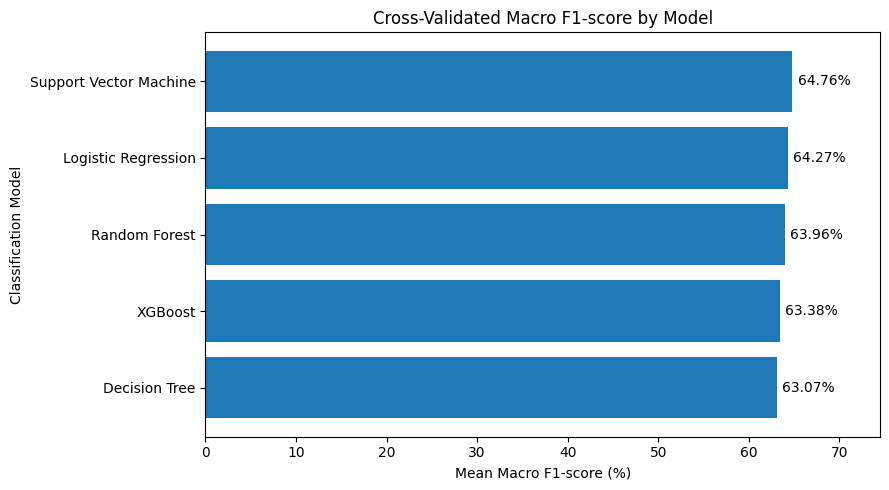

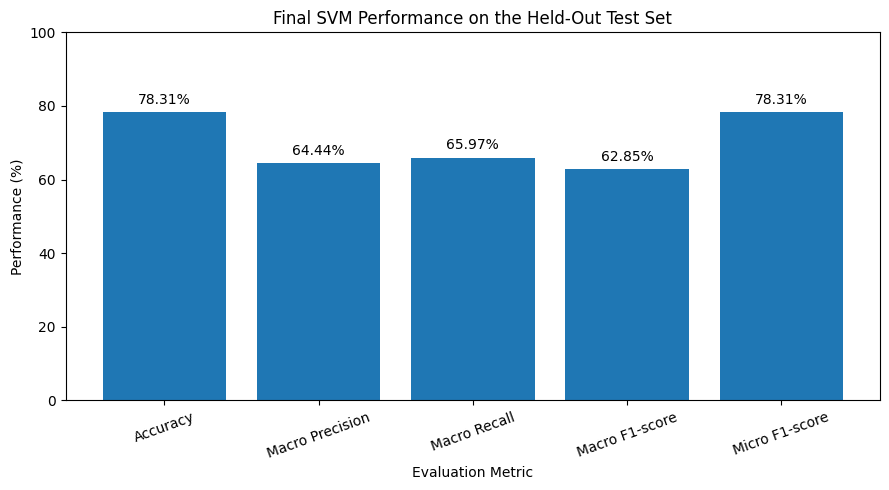

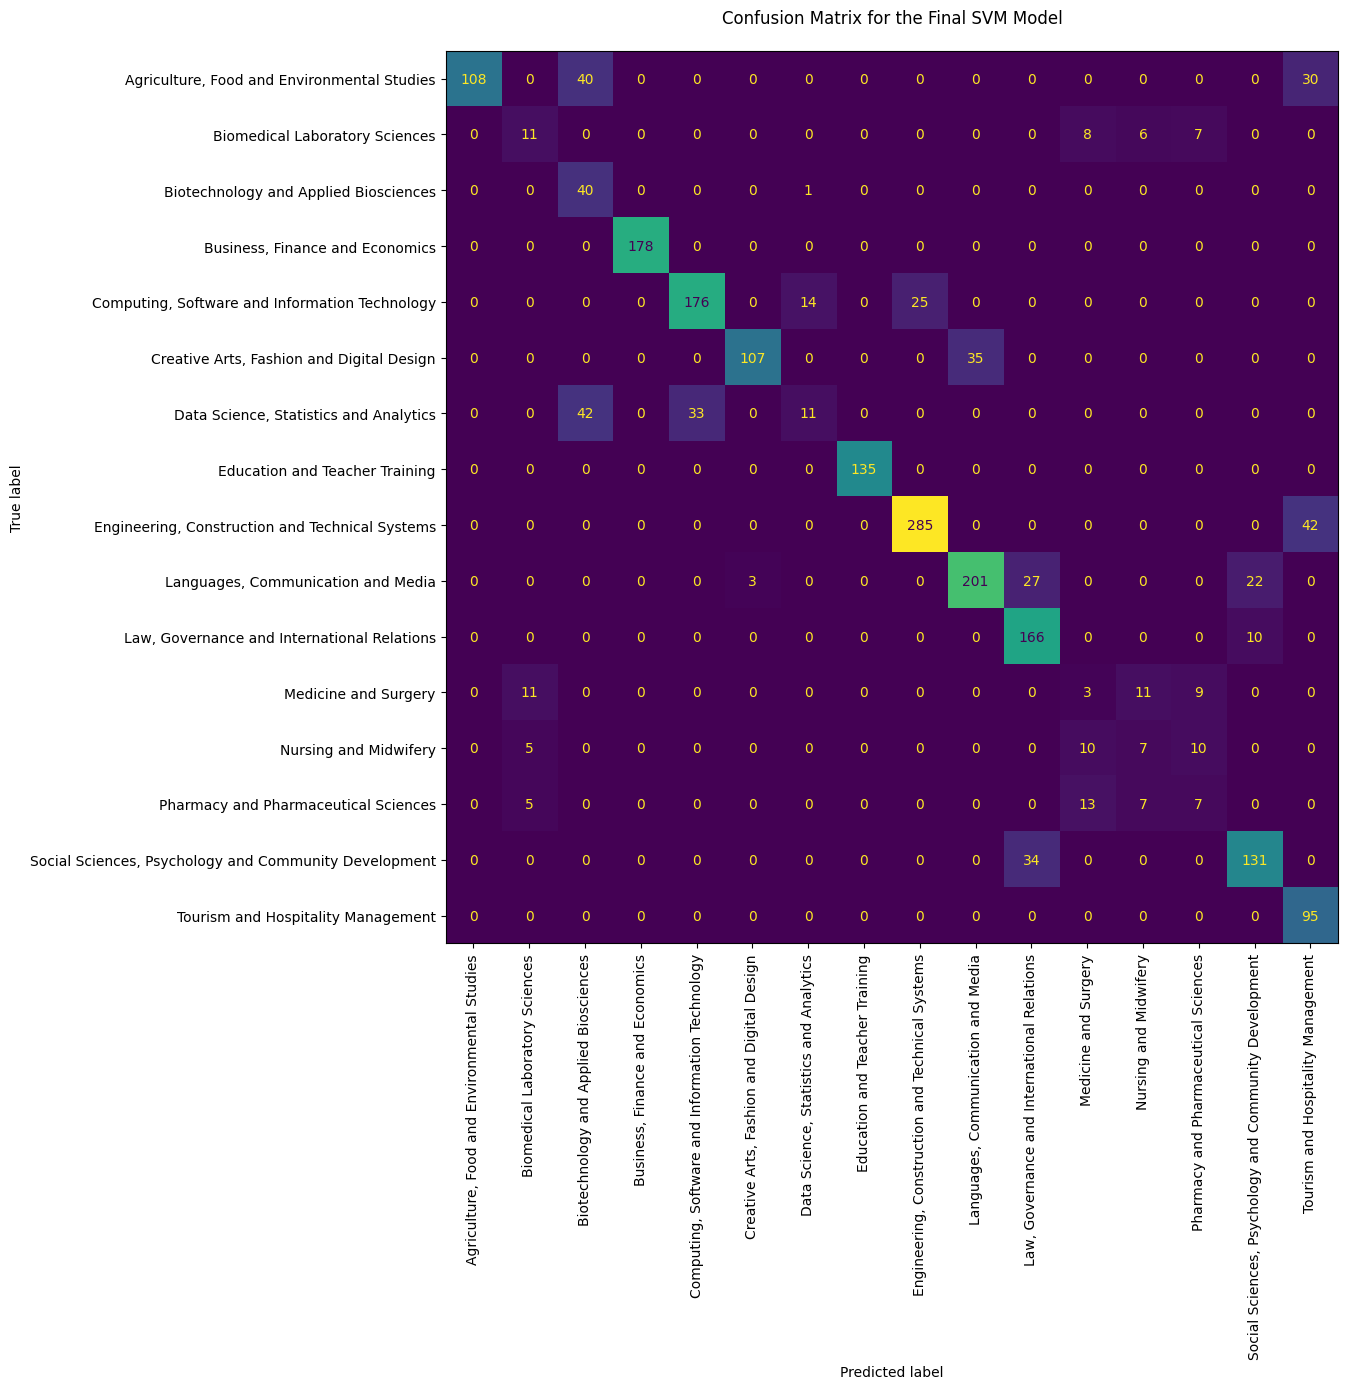

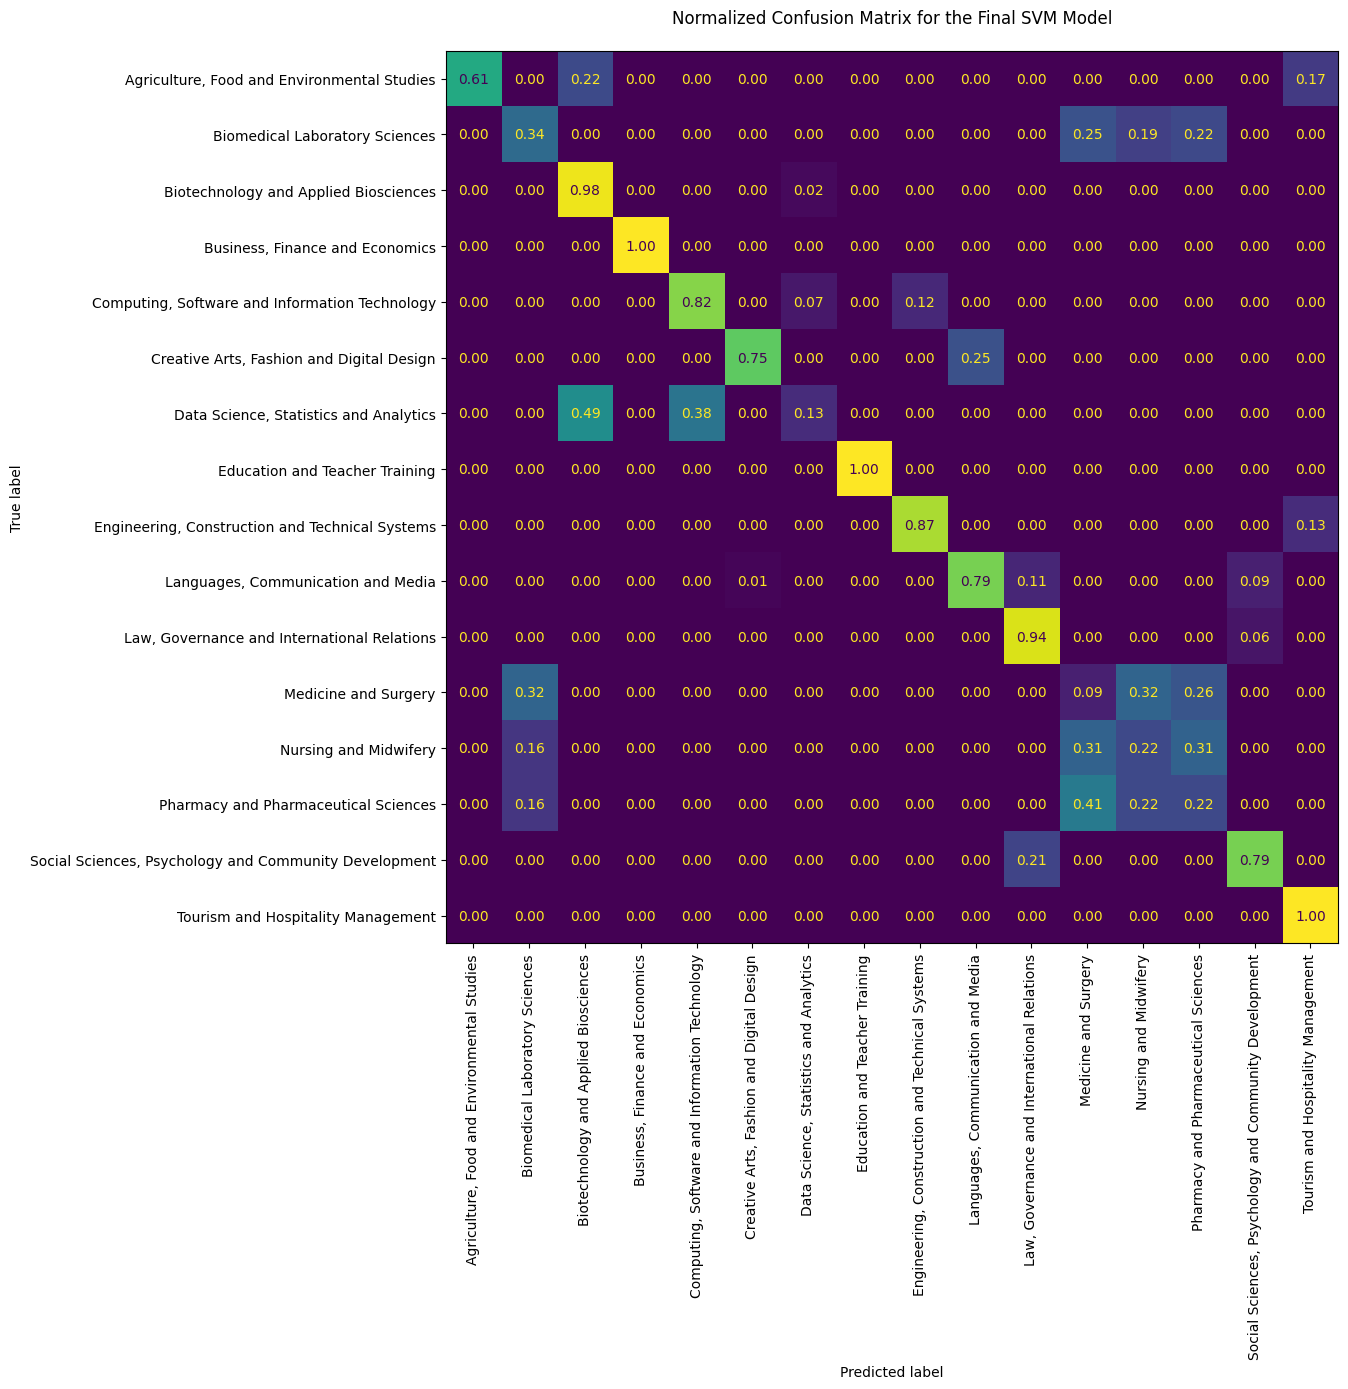

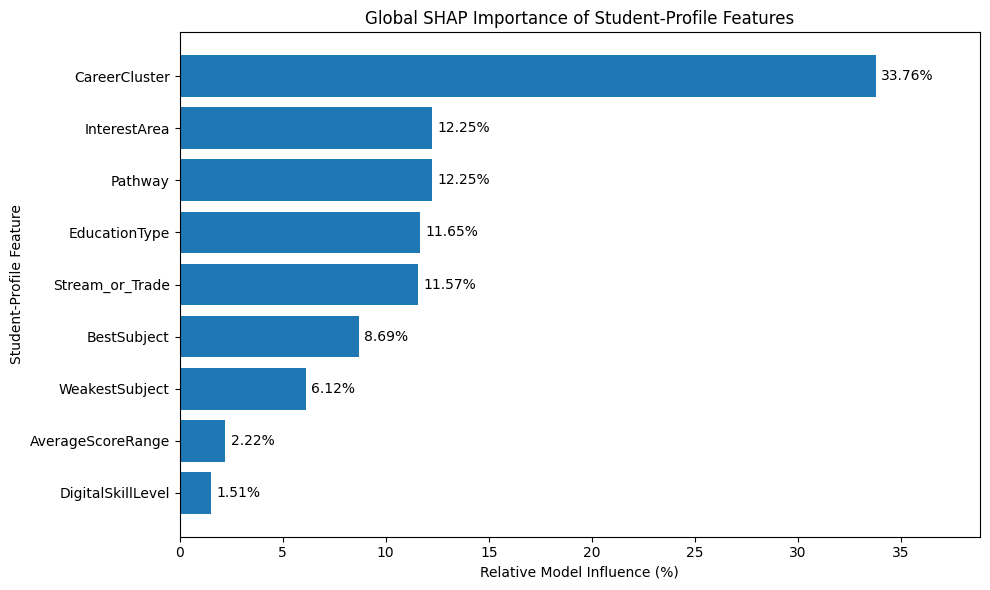

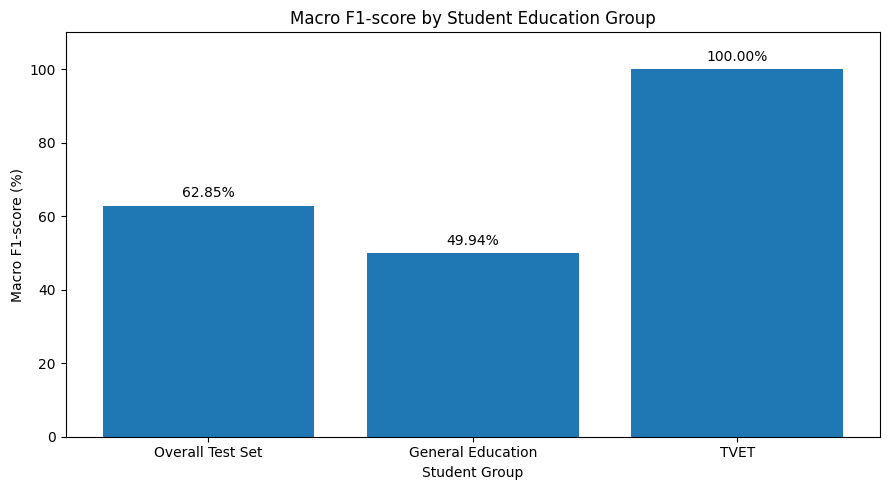

REPORT OUTPUT EXPORT SUMMARY
------------------------------------------------------------
Excel workbook: report_outputs/final_model_results.xlsx
Model comparison figure: report_outputs/model_comparison.png
Final metrics figure: report_outputs/final_test_metrics.png
Raw confusion matrix: report_outputs/confusion_matrix_raw.png
Normalized confusion matrix: report_outputs/confusion_matrix_normalized.png
Global SHAP figure: report_outputs/global_shap_importance.png
Subgroup performance figure: report_outputs/subgroup_performance.png
Model metadata: report_outputs/final_model_metadata.json
Verified model artifact: report_outputs/academic_pathway_model_v2.joblib
ZIP evidence package: /content/academic_pathway_final_evidence.zip

All report outputs exported successfully.


In [66]:
import os
import json
import shutil

# Create an output directory
REPORT_OUTPUT_DIRECTORY = "report_outputs"
os.makedirs(REPORT_OUTPUT_DIRECTORY, exist_ok=True)

# ---------------------------------------------------------
# 1. Export report tables to one Excel workbook
# ---------------------------------------------------------

REPORT_WORKBOOK_PATH = os.path.join(
    REPORT_OUTPUT_DIRECTORY,
    "final_model_results.xlsx"
)

metadata_df = pd.DataFrame(
    list(final_model_metadata.items()),
    columns=["Metadata Field", "Value"]
)

with pd.ExcelWriter(
    REPORT_WORKBOOK_PATH,
    engine="openpyxl"
) as writer:

    model_comparison_df.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )

    final_metrics_df.to_excel(
        writer,
        sheet_name="Final Metrics",
        index=False
    )

    class_performance_ranked.to_excel(
        writer,
        sheet_name="Class Performance"
    )

    classification_report_df.to_excel(
        writer,
        sheet_name="Classification Report"
    )

    subgroup_results_df.to_excel(
        writer,
        sheet_name="Subgroup Results",
        index=False
    )

    global_shap_importance_df.to_excel(
        writer,
        sheet_name="SHAP Importance",
        index=False
    )

    functional_test_results_df.to_excel(
        writer,
        sheet_name="Functional Tests",
        index=False
    )

    functional_validation_df.to_excel(
        writer,
        sheet_name="Validation Checks",
        index=False
    )

    class_distribution_comparison.to_excel(
        writer,
        sheet_name="Class Distribution"
    )

    metadata_df.to_excel(
        writer,
        sheet_name="Model Metadata",
        index=False
    )


# ---------------------------------------------------------
# 2. Export model comparison figure
# ---------------------------------------------------------

model_plot_df = model_comparison_df.sort_values(
    by="Mean Macro F1",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    model_plot_df["Model"],
    model_plot_df["Mean Macro F1"] * 100
)

ax.bar_label(
    bars,
    labels=[
        f"{value * 100:.2f}%"
        for value in model_plot_df["Mean Macro F1"]
    ],
    padding=4
)

ax.set_title(
    "Cross-Validated Macro F1-score by Model"
)
ax.set_xlabel("Mean Macro F1-score (%)")
ax.set_ylabel("Classification Model")

ax.set_xlim(
    0,
    model_plot_df["Mean Macro F1"].max() * 115
)

plt.tight_layout()

MODEL_COMPARISON_FIGURE_PATH = os.path.join(
    REPORT_OUTPUT_DIRECTORY,
    "model_comparison.png"
)

plt.savefig(
    MODEL_COMPARISON_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 3. Export final metrics figure
# ---------------------------------------------------------

final_metrics_plot_df = final_metrics_df.copy()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    final_metrics_plot_df["Evaluation Metric"],
    final_metrics_plot_df["Score"] * 100
)

ax.bar_label(
    bars,
    labels=[
        f"{value * 100:.2f}%"
        for value in final_metrics_plot_df["Score"]
    ],
    padding=4
)

ax.set_title(
    "Final SVM Performance on the Held-Out Test Set"
)
ax.set_xlabel("Evaluation Metric")
ax.set_ylabel("Performance (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()

FINAL_METRICS_FIGURE_PATH = os.path.join(
    REPORT_OUTPUT_DIRECTORY,
    "final_test_metrics.png"
)

plt.savefig(
    FINAL_METRICS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 4. Export raw confusion matrix
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 14))

raw_display = ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=label_encoder.classes_
)

raw_display.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Confusion Matrix for the Final SVM Model",
    pad=20
)

plt.tight_layout()

RAW_CONFUSION_MATRIX_PATH = os.path.join(
    REPORT_OUTPUT_DIRECTORY,
    "confusion_matrix_raw.png"
)

plt.savefig(
    RAW_CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 5. Export normalized confusion matrix
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 14))

normalized_display = ConfusionMatrixDisplay(
    confusion_matrix=normalized_confusion_matrix,
    display_labels=label_encoder.classes_
)

normalized_display.plot(
    ax=ax,
    xticks_rotation=90,
    values_format=".2f",
    colorbar=False
)

ax.set_title(
    "Normalized Confusion Matrix for the Final SVM Model",
    pad=20
)

plt.tight_layout()

NORMALIZED_CONFUSION_MATRIX_PATH = os.path.join(
    REPORT_OUTPUT_DIRECTORY,
    "confusion_matrix_normalized.png"
)

plt.savefig(
    NORMALIZED_CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 6. Export global SHAP importance figure
# ---------------------------------------------------------

shap_plot_df = global_shap_importance_df.sort_values(
    by="Relative Importance (%)",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    shap_plot_df["Student Profile Feature"],
    shap_plot_df["Relative Importance (%)"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in shap_plot_df[
            "Relative Importance (%)"
        ]
    ],
    padding=4
)

ax.set_title(
    "Global SHAP Importance of Student-Profile Features"
)
ax.set_xlabel("Relative Model Influence (%)")
ax.set_ylabel("Student-Profile Feature")

ax.set_xlim(
    0,
    shap_plot_df[
        "Relative Importance (%)"
    ].max() * 1.15
)

plt.tight_layout()

SHAP_FIGURE_PATH = os.path.join(
    REPORT_OUTPUT_DIRECTORY,
    "global_shap_importance.png"
)

plt.savefig(
    SHAP_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 7. Export subgroup comparison figure
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    subgroup_results_df["Student Group"],
    subgroup_results_df["Macro F1-score"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in subgroup_results_df[
            "Macro F1-score"
        ]
    ],
    padding=4
)

ax.set_title(
    "Macro F1-score by Student Education Group"
)
ax.set_xlabel("Student Group")
ax.set_ylabel("Macro F1-score (%)")
ax.set_ylim(0, 110)

plt.tight_layout()

SUBGROUP_FIGURE_PATH = os.path.join(
    REPORT_OUTPUT_DIRECTORY,
    "subgroup_performance.png"
)

plt.savefig(
    SUBGROUP_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 8. Save model metadata as JSON
# ---------------------------------------------------------

METADATA_JSON_PATH = os.path.join(
    REPORT_OUTPUT_DIRECTORY,
    "final_model_metadata.json"
)

with open(
    METADATA_JSON_PATH,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        final_model_metadata,
        metadata_file,
        indent=4,
        default=str
    )


# ---------------------------------------------------------
# 9. Copy the verified deployment model into the folder
# ---------------------------------------------------------

COPIED_MODEL_PATH = os.path.join(
    REPORT_OUTPUT_DIRECTORY,
    "academic_pathway_model_v2.joblib"
)

shutil.copy2(
    MODEL_BUNDLE_PATH,
    COPIED_MODEL_PATH
)


# ---------------------------------------------------------
# 10. Create one downloadable ZIP package
# ---------------------------------------------------------

REPORT_PACKAGE_PATH = shutil.make_archive(
    "academic_pathway_final_evidence",
    "zip",
    REPORT_OUTPUT_DIRECTORY
)


print("REPORT OUTPUT EXPORT SUMMARY")
print("-" * 60)
print(f"Excel workbook: {REPORT_WORKBOOK_PATH}")
print(f"Model comparison figure: {MODEL_COMPARISON_FIGURE_PATH}")
print(f"Final metrics figure: {FINAL_METRICS_FIGURE_PATH}")
print(f"Raw confusion matrix: {RAW_CONFUSION_MATRIX_PATH}")
print(
    f"Normalized confusion matrix: "
    f"{NORMALIZED_CONFUSION_MATRIX_PATH}"
)
print(f"Global SHAP figure: {SHAP_FIGURE_PATH}")
print(f"Subgroup performance figure: {SUBGROUP_FIGURE_PATH}")
print(f"Model metadata: {METADATA_JSON_PATH}")
print(f"Verified model artifact: {COPIED_MODEL_PATH}")
print(f"ZIP evidence package: {REPORT_PACKAGE_PATH}")

print("\nAll report outputs exported successfully.")

## 24. Final Model Conclusion

This notebook developed and evaluated an explainable academic pathway and bridge-course recommendation system for Rwandan General Education and TVET students.

Five classification algorithms were compared using three-fold stratified cross-validation. The Support Vector Machine achieved the highest mean macro F1-score and was selected as the final model.

On the untouched test set of 2,121 student profiles, the final model achieved:

- Accuracy: **78.31%**
- Macro precision: **64.44%**
- Macro recall: **65.97%**
- Macro F1-score: **62.85%**
- Micro F1-score: **78.31%**

The proposal anticipated at least **80% accuracy** and **75% macro F1-score**. The final accuracy was **1.69 percentage points below** the target, while the macro F1-score was **12.15 percentage points below** the target. The proposed technical thresholds were therefore not fully achieved.

The model performed strongly for Business, Education, Engineering, Computing, and several humanities-related categories. Performance was weaker for Medicine, Nursing, Pharmacy, Biomedical Laboratory Sciences, and Data Science because these categories had fewer records and overlapping student-profile characteristics.

SHAP analysis showed that all nine student-profile features influenced the model. Career cluster was the most influential feature, followed by interest area, pathway, education type, stream or TVET trade, and strongest subject.

The final deployment architecture uses the trained SVM to rank broad academic fields. A transparent guidance layer then applies pathway, stream, and TVET-trade eligibility checks, refines the highest eligible field into a specific program direction, maps bridge courses, and identifies alternative or transition pathways. SHAP explains the underlying broad-field model decision.

The technical pipeline tests confirmed that:

- The trained SVM was invoked in all tested scenarios.
- General Education and TVET profiles passed through the same machine-learning pipeline.
- Every test generated bridge courses and an alternative recommendation.
- Every test produced a nine-feature SHAP explanation.
- Lower-score and conflicting profiles generated readiness warnings.
- The saved model produced identical predictions after reloading.

The 100% TVET subgroup performance should be interpreted cautiously because the synthetic dataset contains highly consistent trade-to-program relationships. Broader testing with real and more diverse TVET profiles is required before claiming equivalent real-world performance.

The project provides a functional and measurable decision-support prototype. It does not replace official university admission requirements or professional academic counselling. Future improvements should use more balanced real student data, detailed subject grades, broader user testing, model tuning, and validation across additional deployment environments.


In [67]:
from google.colab import files

files.download(
    "/content/academic_pathway_final_evidence.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>